In [1]:
import pandas as pd

df1= pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.5.csv')
df2 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.25.csv') 
df3 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.125.csv')
df4 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.0625.csv')
df5 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.015625.csv')  
df6= pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_5/Yeast_consolidated_r5_t0.1.csv')

# Your DataFrames
dfs = {
    "0.5": df1,
    "0.25": df2,
    "0.125": df3,
    "0.0625": df4,
    "0.015625": df5,
    "0.1": df6
}

In [2]:
dfs = {
    "0.5": df1,
    "0.25": df2,
    "0.125": df3,
    "0.0625": df4,
    "0.015625": df5,
    "0.1": df6
}

for threshold, df in dfs.items():
    counts = df["Reg"].value_counts()
    filtered = counts[counts > 1]
    num_reg = len(filtered)
    total_interactions = filtered.sum()
    
    print(f"\nThreshold: {threshold}")
    print(f"→ Interactions in more than 1 module: {num_reg}")
    print(f"→ Number of Modules: {total_interactions}")



Threshold: 0.5
→ Interactions in more than 1 module: 3
→ Number of Modules: 6

Threshold: 0.25
→ Interactions in more than 1 module: 10
→ Number of Modules: 25

Threshold: 0.125
→ Interactions in more than 1 module: 23
→ Number of Modules: 52

Threshold: 0.0625
→ Interactions in more than 1 module: 30
→ Number of Modules: 67

Threshold: 0.015625
→ Interactions in more than 1 module: 98
→ Number of Modules: 212

Threshold: 0.1
→ Interactions in more than 1 module: 178
→ Number of Modules: 490


number of edges: 61


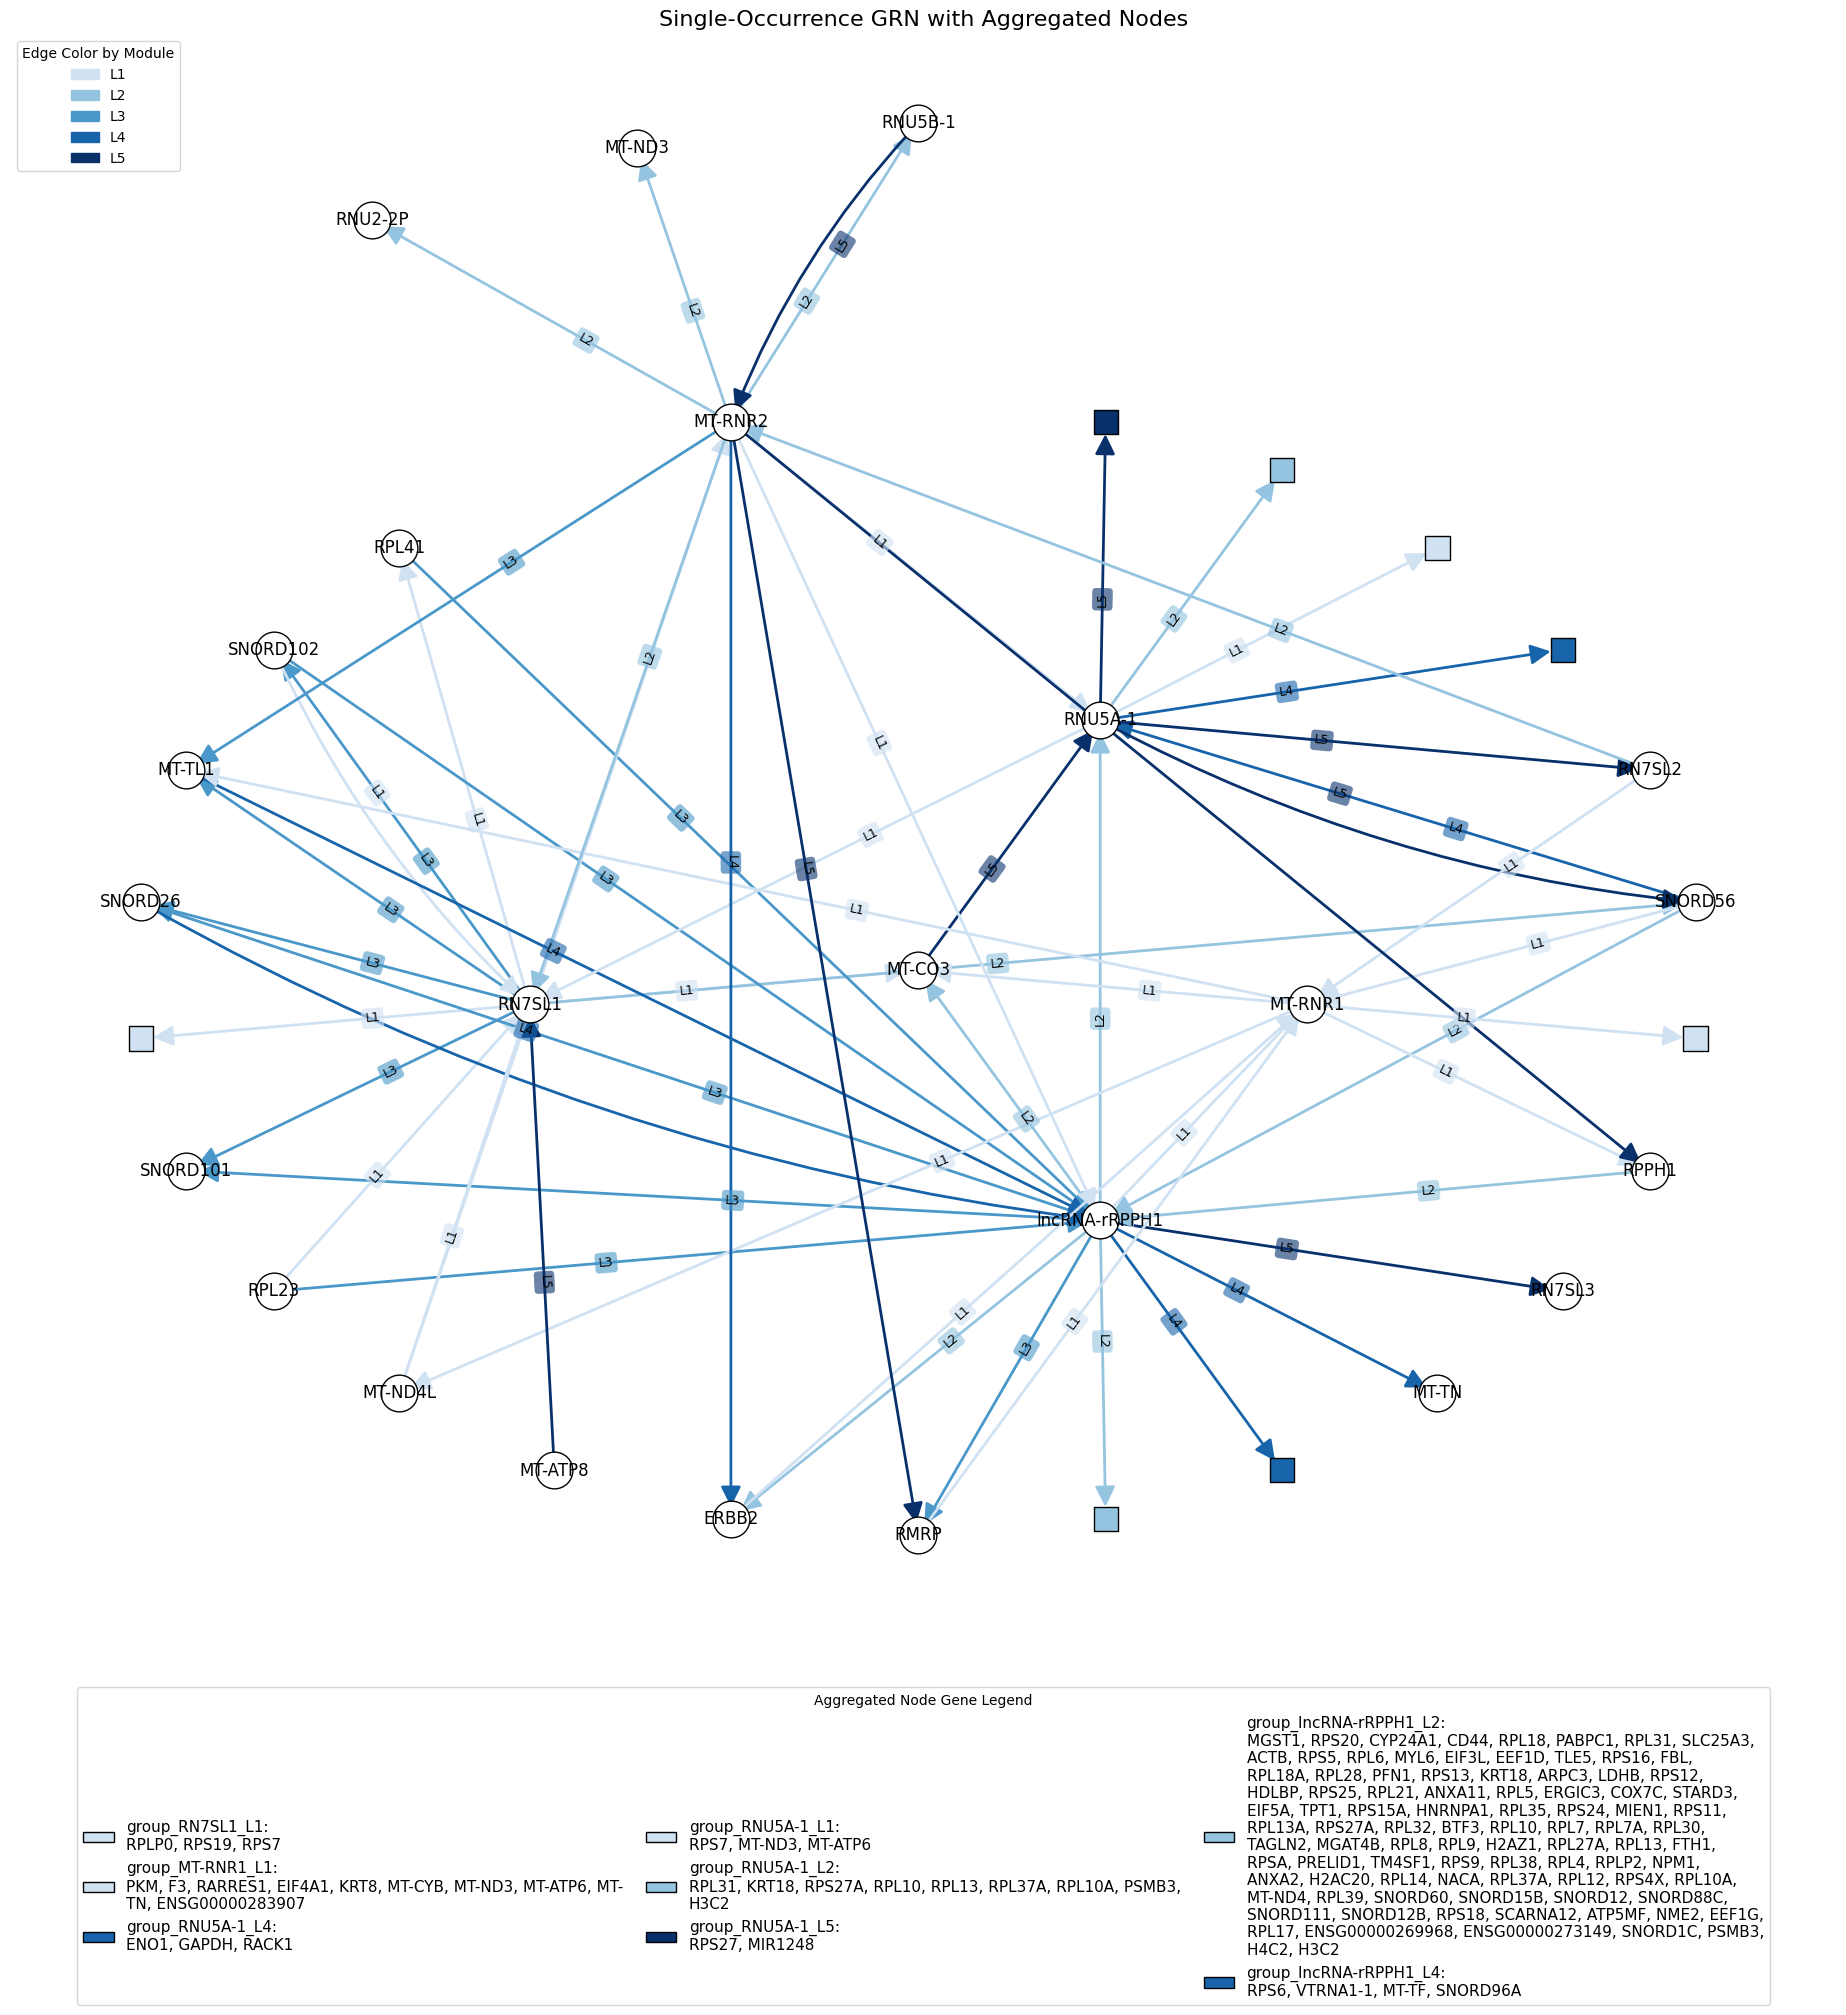

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import textwrap
import matplotlib.gridspec as gridspec

# === Load Data ===
df = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.015625.csv')

# === Count edges and collect modules ===
edge_counts = Counter()
edge_modules = defaultdict(set)
for _, row in df.iterrows():
    edge = (row["Regulator"], row["TargetGene"])
    edge_counts[edge] += 1
    edge_modules[edge].add(row["Module"])

# === Filter only single-occurrence edges ===
single_edges = {e for e, c in edge_counts.items() if c == 1}
df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

# === Build Graph from single-occurrence edges ===
G_full = nx.DiGraph()
node_modules = defaultdict(list)
edge_modules_single = defaultdict(set)
for _, row in df_once.iterrows():
    u, v, mod = row["Regulator"], row["TargetGene"], row["Module"]
    G_full.add_edge(u, v)
    edge_modules_single[(u, v)].add(mod)
    node_modules[u].append(mod)
    node_modules[v].append(mod)

# === Assign dominant module per node ===
node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

# === Group terminal targets for supernodes ===
grouped_targets = defaultdict(list)
for u, v in G_full.edges():
    if v in terminal_nodes:
        grouped_targets[(u, node_cluster[v])].append(v)

# === Build simplified graph ===
G = nx.DiGraph()
new_node_cluster = {}
new_edge_modules = {}
supernodes = {}
supernode_module = {}

for u, v in G_full.edges():
    if v in terminal_nodes:
        continue
    G.add_edge(u, v)
    new_edge_modules[(u, v)] = edge_modules_single[(u, v)]
    new_node_cluster[u] = node_cluster[u]
    new_node_cluster[v] = node_cluster[v]

for (reg, mod), targets in grouped_targets.items():
    if len(targets) == 1:
        v = targets[0]
        G.add_edge(reg, v)
        new_edge_modules[(reg, v)] = edge_modules_single[(reg, v)]
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[v] = node_cluster[v]
    else:
        sn = f"group_{reg}_{mod}"
        G.add_edge(reg, sn)
        new_edge_modules[(reg, sn)] = {mod}
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[sn] = mod
        supernodes[sn] = targets
        supernode_module[sn] = mod

# === Color Mapping ===
all_modules = sorted({m for mods in new_edge_modules.values() for m in mods})
min_val, max_val = 0.2, 1.0
steps = len(all_modules) - 1 if len(all_modules) > 1 else 1
module_to_intensity = {
    mod: min_val + i * (max_val - min_val) / steps for i, mod in enumerate(all_modules)
}
cmap = plt.colormaps["Blues"]

# === Layout ===
pos = graphviz_layout(G, prog="twopi", root='MT-CO3')

# === Create Figure ===
fig = plt.figure(figsize=(20, 26))
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 1])
ax_graph = plt.subplot(gs[0])
ax_legend = plt.subplot(gs[1])
ax_legend.axis("off")

# === Draw Nodes ===
regular_nodes = [n for n in G.nodes() if n not in supernodes]
supernode_list = list(supernodes)

nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes,
                       node_color="white", edgecolors="black",
                       node_shape='o', node_size=700, ax=ax_graph)

nx.draw_networkx_nodes(G, pos, nodelist=supernode_list,
    node_color=[cmap(module_to_intensity[supernode_module[n]]) for n in supernode_list],
    edgecolors="black", node_shape='s', node_size=300, ax=ax_graph)

nx.draw_networkx_labels(G, pos, labels={n: n for n in regular_nodes},
                        font_size=12, ax=ax_graph)

# === Identify bidirectional edges ===
mutual_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u) and (v, u) not in mutual_edges:
        mutual_edges.add((u, v))

# === Precompute edge colors ===
edge_to_color = {}
for u, v in G.edges():
    modules = sorted(new_edge_modules.get((u, v), []))
    if modules:
        avg_intensity = sum(module_to_intensity[m] for m in modules) / len(modules)
        edge_to_color[(u, v)] = cmap(avg_intensity)

# === Draw Edges ===
drawn_mutual = set()
for u, v, data in G.edges(data=True):
    edge_color = edge_to_color[(u, v)]

    # Use curved line if it's the second in a mutual pair
    if (v, u) in mutual_edges and (v, u) not in drawn_mutual:
        connection = 'arc3,rad=0.1'
        drawn_mutual.add((u, v))
    else:
        connection = 'arc3,rad=0.0'

    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        edge_color=[edge_color], arrows=True,
        arrowstyle='-|>', arrowsize=30, width=2,
        connectionstyle=connection, ax=ax_graph
    )

# === Edge Labels with Matching Colors ===
edge_labels = {(u, v): ", ".join(sorted(mods)) for (u, v), mods in new_edge_modules.items()}
for (u, v), label in edge_labels.items():
    edge_color = edge_to_color.get((u, v), "white")
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels={(u, v): label},
        font_size=9, label_pos=0.4,
        bbox=dict(boxstyle='round',
                  facecolor=edge_color,
                  edgecolor='none',
                  alpha=0.6),
        ax=ax_graph
    )

ax_graph.set_title("Single-Occurrence GRN with Aggregated Nodes", fontsize=16)
ax_graph.axis("off")

# === Legends ===
legend_lines = [
    Patch(color=cmap(module_to_intensity[m]), label=m) for m in all_modules
]

legend_supernodes = []
supernode_labels = []
for sn in supernode_list:
    mod = supernode_module[sn]
    targets = supernodes[sn]
    wrapped = "\n".join(textwrap.wrap(", ".join(targets), width=60))
    color = cmap(module_to_intensity[mod])
    legend_supernodes.append(Patch(facecolor=color, edgecolor='black'))
    supernode_labels.append(f"{sn}:\n{wrapped}")

ax_graph.legend(handles=legend_lines, title="Edge Color by Module", loc='upper left')

legend_super = ax_legend.legend(
    handles=legend_supernodes, labels=supernode_labels,
    loc='upper center', bbox_to_anchor=(0.5, 1.12),
    fontsize=11, title="Aggregated Node Gene Legend", ncol=3,
    frameon=True, columnspacing=1.5
)
print("number of edges:", G.number_of_edges())

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, bottom=0.2, top=0.95)
plt.show()


In [7]:
# === Supernode Edge Reduction ===

# Count edges before and after supernode aggregation
edges_before_supernodes = len(G_full.edges())
edges_after_supernodes = len(G.edges())

# How many edges were reduced
edge_reduction_supernodes = edges_before_supernodes - edges_after_supernodes
percent_reduction_supernodes = (edge_reduction_supernodes / edges_before_supernodes) * 100

print(f"Edges before node aggregation: {edges_before_supernodes}")
print(f"Edges after node aggregation: {edges_after_supernodes}")
print(f"Edge reduction due to aggregated nodes: {edge_reduction_supernodes}")
print(f"Percent edge reduction due to aggregated nodes: {percent_reduction_supernodes:.2f}%")


Edges before node aggregation: 180
Edges after node aggregation: 61
Edge reduction due to aggregated nodes: 119
Percent edge reduction due to aggregated nodes: 66.11%


# Calculation for Human dataset + Yeast dataset scr size 5

In [9]:
import pandas as pd

df1= pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.5.csv')
df2 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.25.csv') 
df3 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.125.csv')
df4 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.0625.csv')
df5 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Human_coronavirus/HS_consolidated_r5_t0.015625.csv')  
df6= pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_5/Yeast_consolidated_r5_t0.1.csv')

# Your DataFrames
dfs = {
    "0.5": df1,
    "0.25": df2,
    "0.125": df3,
    "0.0625": df4,
    "0.015625": df5,
    "0.1": df6
}

from collections import defaultdict, Counter
import networkx as nx
import pandas as pd

summary_data = []

for threshold, df in dfs.items():
    total_interactions = len(df)

    # === Multi-module calculation ===
    counts = df["Reg"].value_counts()
    multi_module_regulators = counts[counts > 1]
    num_multi_module = len(multi_module_regulators)
    total_multi_module_interactions = multi_module_regulators.sum()

    single_module_interactions = total_interactions - total_multi_module_interactions
    edge_reduction_by = ((total_multi_module_interactions - num_multi_module) / total_multi_module_interactions) * 100

    # === Filter only single-module interactions ===
    edge_counts = Counter()
    edge_modules = defaultdict(set)
    for _, row in df.iterrows():
        edge = (row["Regulator"], row["TargetGene"])
        edge_counts[edge] += 1
        edge_modules[edge].add(row["Module"])

    single_edges = {e for e, c in edge_counts.items() if c == 1}
    df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

    # === Build full graph before node aggregation ===
    G_full = nx.DiGraph()
    node_modules = defaultdict(list)
    edge_modules_single = defaultdict(set)
    for _, row in df_once.iterrows():
        u, v, mod = row["Regulator"], row["TargetGene"], row["Module"]
        G_full.add_edge(u, v)
        edge_modules_single[(u, v)].add(mod)
        node_modules[u].append(mod)
        node_modules[v].append(mod)

    node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
    terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

    grouped_targets = defaultdict(list)
    for u, v in G_full.edges():
        if v in terminal_nodes:
            grouped_targets[(u, node_cluster[v])].append(v)

    # === Build simplified graph with saggregated nodes ===
    G = nx.DiGraph()
    supernodes = {}

    for u, v in G_full.edges():
        if v in terminal_nodes:
            continue
        G.add_edge(u, v)

    for (reg, mod), targets in grouped_targets.items():
        if len(targets) == 1:
            v = targets[0]
            G.add_edge(reg, v)
        else:
            sn = f"group_{reg}_{mod}"
            G.add_edge(reg, sn)
            supernodes[sn] = targets

    # === Calculate edge reduction ===
    edges_before = len(G_full.edges())
    edges_after = len(G.edges())
    edge_reduction_supernodes = edges_before - edges_after
    percent_reduction_supernodes = (edge_reduction_supernodes / edges_before) * 100 if edges_before > 0 else 0

    # === Save summary ===
    summary_data.append({
    "Threshold": threshold,
    "Total Interactions": total_interactions,
    "Unique Multi-module Interactions": num_multi_module,
    "Total Multi-module Interactions": total_multi_module_interactions,
    "multi-modal percentage": round((total_multi_module_interactions / total_interactions) * 100, 2),
    "Edge Reduction from Combining Multi-module Interactions (%)": round(edge_reduction_by, 2),
    "Single Module Interactions": single_module_interactions,
     "Edges After Node Aggregation": edges_after,
    "Edge Reduction from Aggregated Nodes (%)": round(percent_reduction_supernodes, 2)
   
})


# === Create final dataframe ===
summary_df1 = pd.DataFrame(summary_data)
#summary_df.set_index("Threshold", inplace=True)
#summary_df = summary_df.sort_values(by="Threshold", key=lambda x: x.astype(float))
#summary_df.reset_index(drop=True, inplace=True)

summary_df1


,Threshold,Total Interactions,Unique Multi-module Interactions,Total Multi-module Interactions,multi-modal percentage,Edge Reduction from Combining Multi-module Interactions (%),Single Module Interactions,Edges After Node Aggregation,Edge Reduction from Aggregated Nodes (%)
0,0.5,18,3,6,33.33,50.00,12,11,8.33
1,0.25,46,10,25,54.35,60.00,21,19,9.52
2,0.125,87,23,52,59.77,55.77,35,27,22.86
3,0.0625,136,30,67,49.26,55.22,69,43,37.68
4,0.015625,392,98,212,54.08,53.77,180,61,66.11
5,0.1,677,178,490,72.38,63.67,187,180,3.74


# Calculation for Yeast dataset scr size 10 without including biotype columns

In [10]:
df1 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_10/Yeast_consolidated_scr10_r5_t0.1_biotype.csv')
df2 = pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_10/Yeast_consolidated_scr10_r5_t0.05_biotype.csv') 
df3= pd.read_csv('/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_10/Yeast_consolidated_scr10_r5_t0.01.csv')

In [11]:
dfs = {
    "0.1": df1,
    "0.05": df2,
    "0.01": df3
}

for threshold, df in dfs.items():
    counts = df["Reg"].value_counts()
    filtered = counts[counts > 1]
    num_reg = len(filtered)
    total_interactions = filtered.sum()
    
    print(f"\nThreshold: {threshold}")
    print(f"→ Interactions in more than 1 module: {num_reg}")
    print(f"→ Number of Modules: {total_interactions}")



Threshold: 0.1
→ Interactions in more than 1 module: 87
→ Number of Modules: 266

Threshold: 0.05
→ Interactions in more than 1 module: 269
→ Number of Modules: 797

Threshold: 0.01
→ Interactions in more than 1 module: 1563
→ Number of Modules: 4238


In [12]:
from collections import defaultdict, Counter
import networkx as nx
import pandas as pd

summary_data = []

for threshold, df in dfs.items():
    total_interactions = len(df)

    # === Multi-module calculation ===
    counts = df["Reg"].value_counts()
    multi_module_regulators = counts[counts > 1]
    num_multi_module = len(multi_module_regulators)
    total_multi_module_interactions = multi_module_regulators.sum()

    single_module_interactions = total_interactions - total_multi_module_interactions
    edge_reduction_by = ((total_multi_module_interactions - num_multi_module) / total_multi_module_interactions) * 100

    # === Filter only single-module interactions ===
    edge_counts = Counter()
    edge_modules = defaultdict(set)
    for _, row in df.iterrows():
        edge = (row["Regulator"], row["TargetGene"])
        edge_counts[edge] += 1
        edge_modules[edge].add(row["Module"])

    single_edges = {e for e, c in edge_counts.items() if c == 1}
    df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

    # === Build full graph before node aggregation ===
    G_full = nx.DiGraph()
    node_modules = defaultdict(list)
    edge_modules_single = defaultdict(set)
    for _, row in df_once.iterrows():
        u, v, mod = row["Regulator"], row["TargetGene"], row["Module"]
        G_full.add_edge(u, v)
        edge_modules_single[(u, v)].add(mod)
        node_modules[u].append(mod)
        node_modules[v].append(mod)

    node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
    terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

    grouped_targets = defaultdict(list)
    for u, v in G_full.edges():
        if v in terminal_nodes:
            grouped_targets[(u, node_cluster[v])].append(v)

    # === Build simplified graph with aggregated nodes ===
    G = nx.DiGraph()
    supernodes = {}

    for u, v in G_full.edges():
        if v in terminal_nodes:
            continue
        G.add_edge(u, v)

    for (reg, mod), targets in grouped_targets.items():
        if len(targets) == 1:
            v = targets[0]
            G.add_edge(reg, v)
        else:
            sn = f"group_{reg}_{mod}"
            G.add_edge(reg, sn)
            supernodes[sn] = targets

    # === Calculate edge reduction ===
    edges_before = len(G_full.edges())
    edges_after = len(G.edges())
    edge_reduction_supernodes = edges_before - edges_after
    percent_reduction_supernodes = (edge_reduction_supernodes / edges_before) * 100 if edges_before > 0 else 0

    # === Save summary ===
    summary_data.append({
    "Threshold": threshold,
    "Total Interactions": total_interactions,
    "Unique Multi-module Interactions": num_multi_module,
    "Total Multi-module Interactions": total_multi_module_interactions,
    "multi-modal percentage": round((total_multi_module_interactions / total_interactions) * 100, 2),
    "Edge Reduction from Combining Multi-module Interactions (%)": round(edge_reduction_by, 2),
    "Single Module Interactions": single_module_interactions,
     "Edges After Node Aggregation": edges_after,
    "Edge Reduction from Aggregated Nodes (%)": round(percent_reduction_supernodes, 2)
   
})


# === Create final dataframe ===
summary_df2 = pd.DataFrame(summary_data)
#summary_df.set_index("Threshold", inplace=True)
#summary_df = summary_df.sort_values(by="Threshold", key=lambda x: x.astype(float))
#summary_df.reset_index(drop=True, inplace=True)

summary_df2


,Threshold,Total Interactions,Unique Multi-module Interactions,Total Multi-module Interactions,multi-modal percentage,Edge Reduction from Combining Multi-module Interactions (%),Single Module Interactions,Edges After Node Aggregation,Edge Reduction from Aggregated Nodes (%)
0,0.1,337,87,266,78.93,67.29,71,64,9.86
1,0.05,1121,269,797,71.10,66.25,324,280,13.58
2,0.01,7015,1563,4238,60.41,63.12,2777,1627,41.41


Best root node (excluding supernodes): YML129C
number of edges: 64
number of terminal nodes: 15


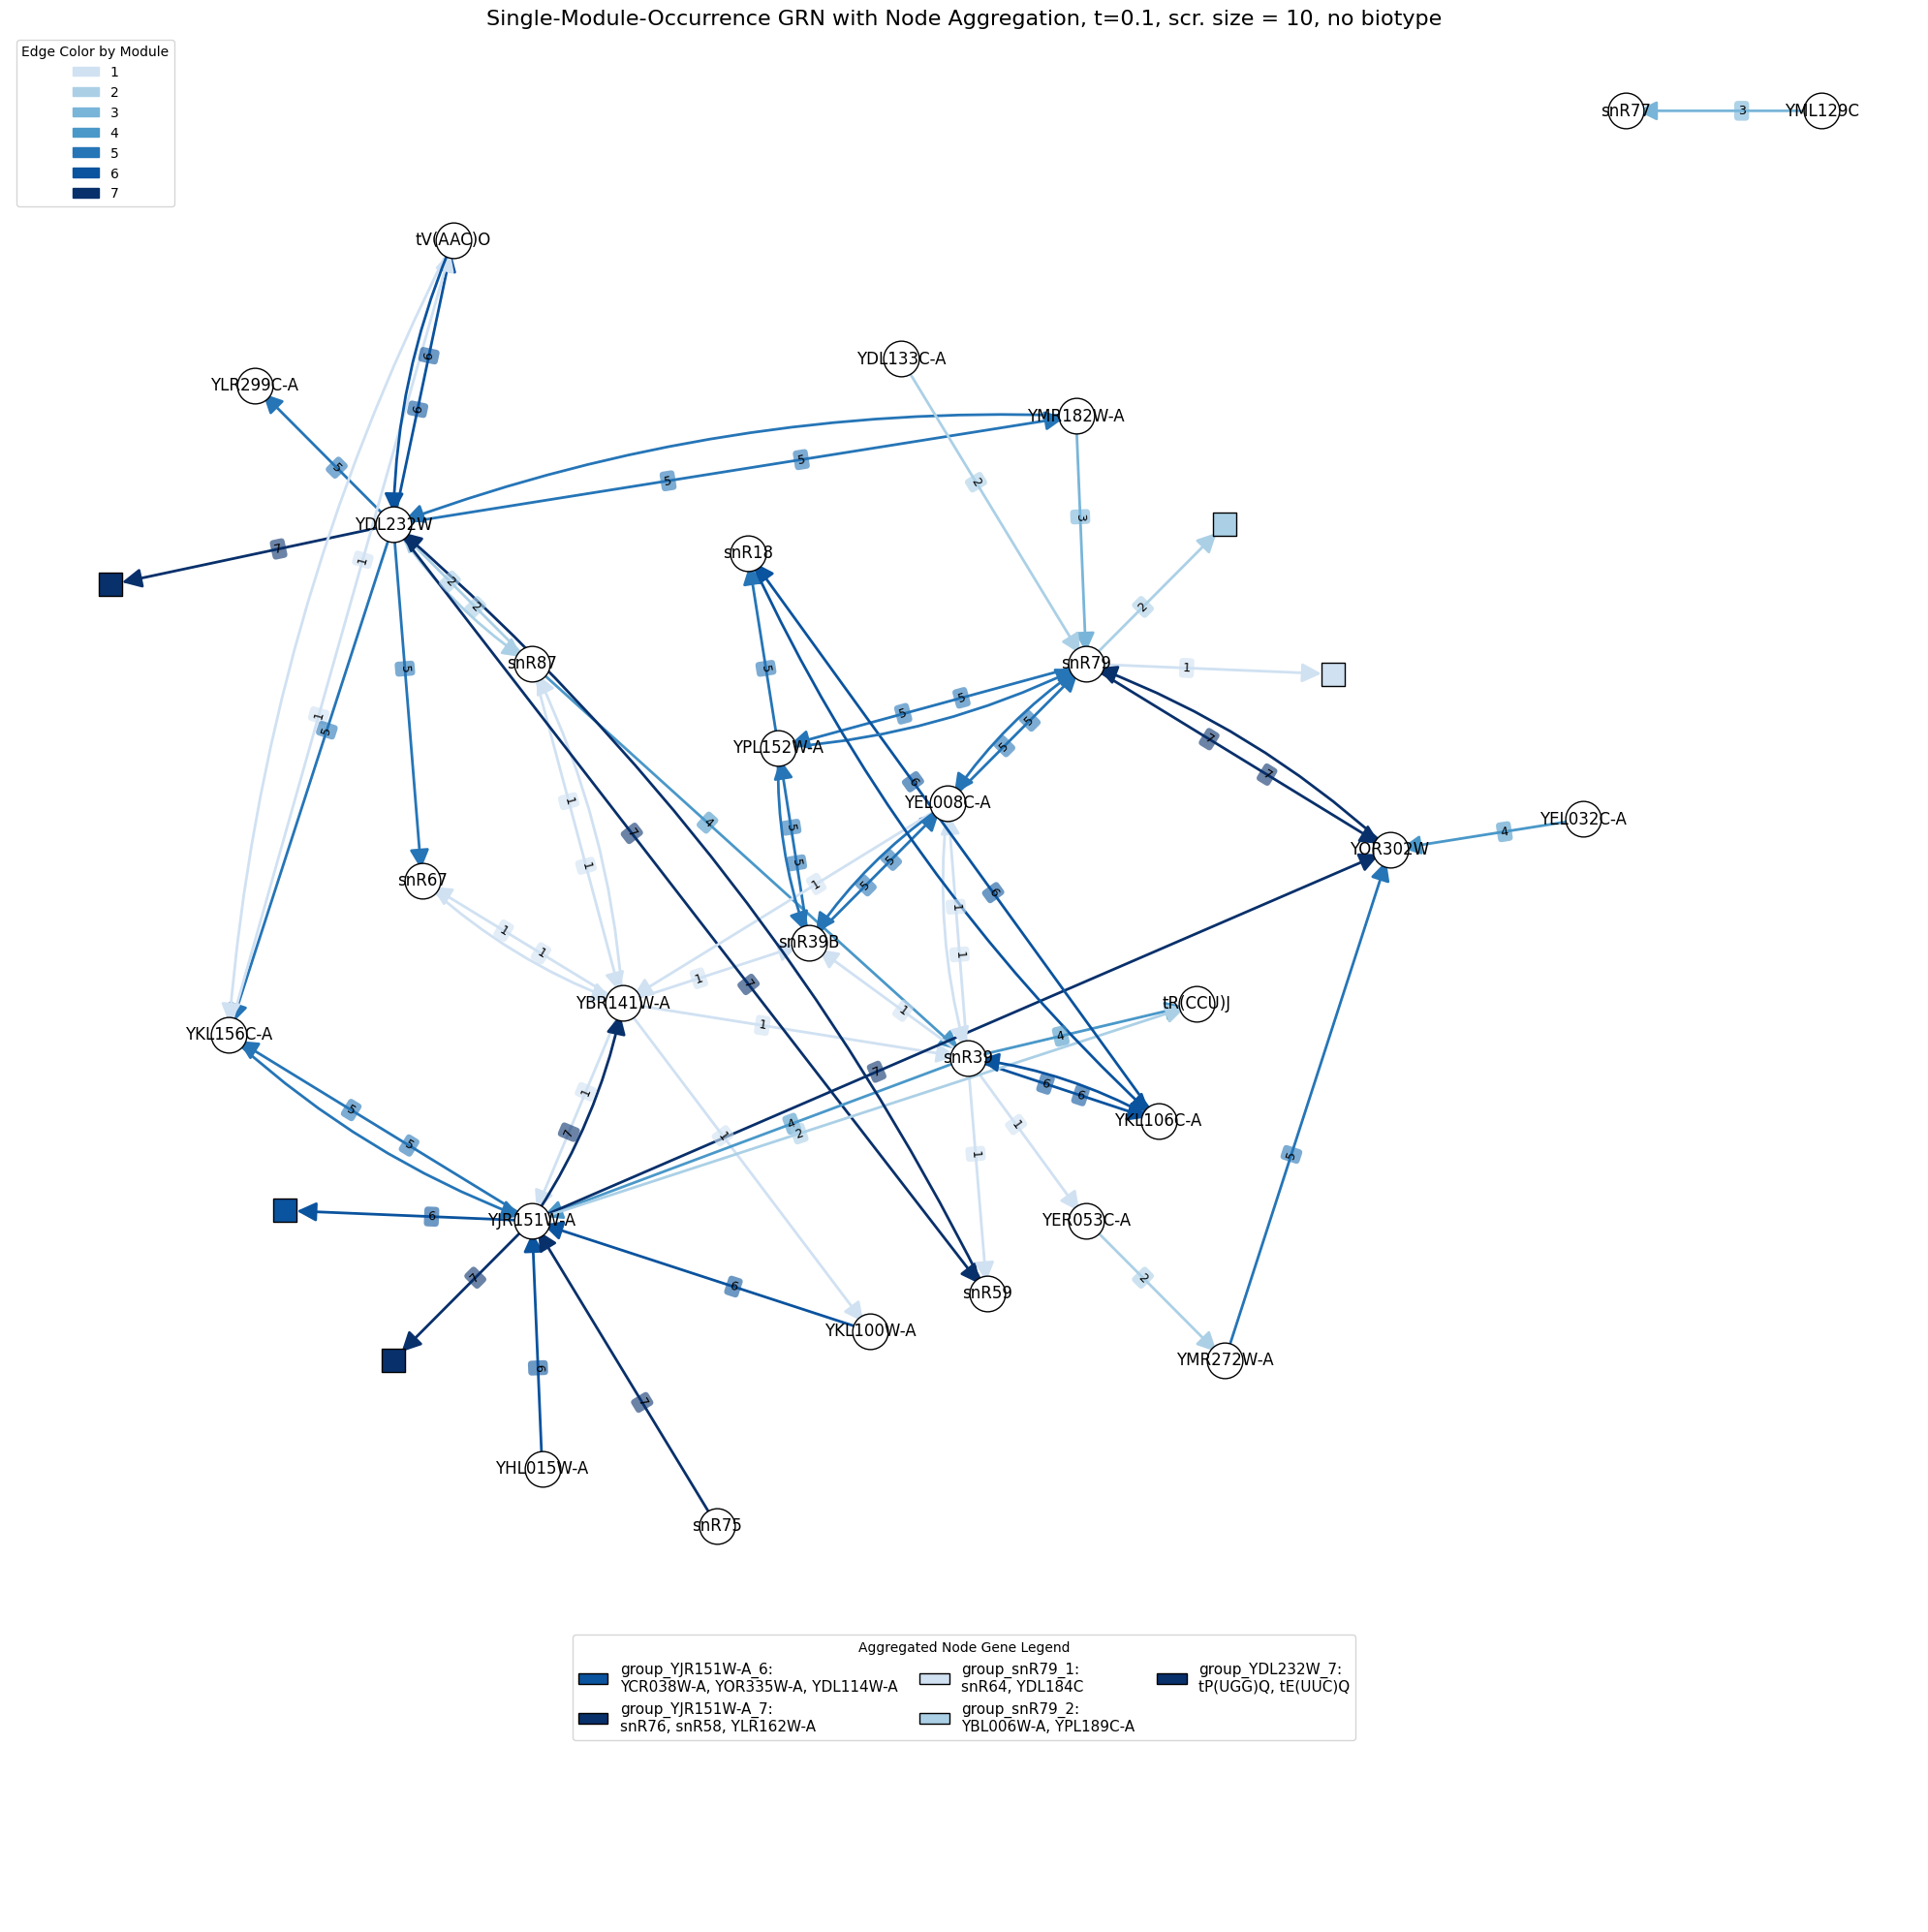

In [13]:
# example for 0.1 threshold, single module, no biotype
#yeast
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import textwrap
import matplotlib.gridspec as gridspec
import re

# === Load Data ===
df = pd.read_csv("/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_10/Yeast_consolidated_scr10_r5_t0.1_biotype.csv")

# === Count edges and collect modules ===
edge_counts = Counter()
edge_modules = defaultdict(set)
for _, row in df.iterrows():
    edge = (row["Regulator"], row["TargetGene"])
    edge_counts[edge] += 1
    edge_modules[edge].add(row["Module"])

# === Filter only single-occurrence edges ===
single_edges = {e for e, c in edge_counts.items() if c == 1}
df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

# === Build Graph from single-occurrence edges ===
G_full = nx.DiGraph()
node_modules = defaultdict(list)
edge_modules_single = defaultdict(set)
for _, row in df_once.iterrows():
    u, v, mod = row["Regulator"], row["TargetGene"], row["Module"]
    G_full.add_edge(u, v)
    edge_modules_single[(u, v)].add(mod)
    node_modules[u].append(mod)
    node_modules[v].append(mod)

# === Assign dominant module per node ===
node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

# === Group terminal targets for supernodes ===
grouped_targets = defaultdict(list)
for u, v in G_full.edges():
    if v in terminal_nodes:
        grouped_targets[(u, node_cluster[v])].append(v)

# === Build simplified graph ===
G = nx.DiGraph()
new_node_cluster = {}
new_edge_modules = {}
supernodes = {}
supernode_module = {}

for u, v in G_full.edges():
    if v in terminal_nodes:
        continue
    G.add_edge(u, v)
    new_edge_modules[(u, v)] = edge_modules_single[(u, v)]
    new_node_cluster[u] = node_cluster[u]
    new_node_cluster[v] = node_cluster[v]

for (reg, mod), targets in grouped_targets.items():
    if len(targets) == 1:
        v = targets[0]
        G.add_edge(reg, v)
        new_edge_modules[(reg, v)] = edge_modules_single[(reg, v)]
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[v] = node_cluster[v]
    else:
        sn = f"group_{reg}_{mod}"
        G.add_edge(reg, sn)
        new_edge_modules[(reg, sn)] = {mod}
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[sn] = mod
        supernodes[sn] = targets
        supernode_module[sn] = mod

# === Color Mapping ===
def natural_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split(r'(\d+)', s)]

all_modules = sorted({m for mods in new_edge_modules.values() for m in mods})
min_val, max_val = 0.2, 1.0
steps = len(all_modules) - 1 if len(all_modules) > 1 else 1
module_to_intensity = {
    mod: min_val + i * (max_val - min_val) / steps for i, mod in enumerate(all_modules)
}
cmap = plt.colormaps["Blues"]

# === Layout ===
#pos = graphviz_layout(G, prog="twopi", root='MT-CO3')
# === Identify optimal root node (minimum average shortest path length, exclude supernodes) ===
try:
    candidate_nodes = [n for n in G.nodes() if n not in supernodes]
    lengths = {}

    for node in candidate_nodes:
        sp = nx.single_source_shortest_path_length(G, node)
        # Only count shortest paths to other non-supernodes
        reachable = [t for t in sp if t != node and t not in supernodes]
        if reachable:
            avg_length = sum(sp[t] for t in reachable) / len(reachable)
            lengths[node] = avg_length

    best_root = min(lengths, key=lengths.get)
    print(f"Best root node (excluding supernodes): {best_root}")
except:
    best_root = candidate_nodes[0] if candidate_nodes else list(G.nodes())[0]
    print("No valid root found — using fallback.")


pos = graphviz_layout(G, prog="twopi", root=best_root)

# === Create Figure ===
fig = plt.figure(figsize=(20, 26))
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 1])
ax_graph = plt.subplot(gs[0])
ax_legend = plt.subplot(gs[1])
ax_legend.axis("off")

# === Draw Nodes ===
regular_nodes = [n for n in G.nodes() if n not in supernodes]
supernode_list = list(supernodes)

nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes,
                       node_color="white", edgecolors="black",
                       node_shape='o', node_size=700, ax=ax_graph)

nx.draw_networkx_nodes(G, pos, nodelist=supernode_list,
    node_color=[cmap(module_to_intensity[supernode_module[n]]) for n in supernode_list],
    edgecolors="black", node_shape='s', node_size=300, ax=ax_graph)

nx.draw_networkx_labels(G, pos, labels={n: n for n in regular_nodes},
                        font_size=12, ax=ax_graph)

# === Identify bidirectional edges ===
mutual_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u) and (v, u) not in mutual_edges:
        mutual_edges.add((u, v))

# === Precompute edge colors ===
edge_to_color = {}
for u, v in G.edges():
    modules = sorted(new_edge_modules.get((u, v), []))
    if modules:
        avg_intensity = sum(module_to_intensity[m] for m in modules) / len(modules)
        edge_to_color[(u, v)] = cmap(avg_intensity)

# === Draw Edges ===
drawn_mutual = set()
for u, v, data in G.edges(data=True):
    edge_color = edge_to_color[(u, v)]

    # Use curved line if it's the second in a mutual pair
    if (v, u) in mutual_edges and (v, u) not in drawn_mutual:
        connection = 'arc3,rad=0.1'
        drawn_mutual.add((u, v))
    else:
        connection = 'arc3,rad=0.0'

    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        edge_color=[edge_color], arrows=True,
        arrowstyle='-|>', arrowsize=30, width=2,
        connectionstyle=connection, ax=ax_graph
    )

# === Edge Labels with Matching Colors ===
edge_labels = {(u, v): ", ".join(sorted(map(str, mods))) for (u, v), mods in new_edge_modules.items()}
for (u, v), label in edge_labels.items():
    edge_color = edge_to_color.get((u, v), "white")
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels={(u, v): label},
        font_size=9, label_pos=0.4,
        bbox=dict(boxstyle='round',
                  facecolor=edge_color,
                  edgecolor='none',
                  alpha=0.6),
        ax=ax_graph
    )

ax_graph.set_title("Single-Module-Occurrence GRN with Node Aggregation, t=0.1, scr. size = 10, no biotype", fontsize=16)
ax_graph.axis("off")

# === Legends ===
legend_lines = [
    Patch(color=cmap(module_to_intensity[m]), label=m) for m in all_modules
]

legend_supernodes = []
supernode_labels = []
for sn in supernode_list:
    mod = supernode_module[sn]
    targets = supernodes[sn]
    wrapped = "\n".join(textwrap.wrap(", ".join(targets), width=60))
    color = cmap(module_to_intensity[mod])
    legend_supernodes.append(Patch(facecolor=color, edgecolor='black'))
    supernode_labels.append(f"{sn}:\n{wrapped}")

ax_graph.legend(handles=legend_lines, title="Edge Color by Module", loc='upper left')

legend_super = ax_legend.legend(
    handles=legend_supernodes, labels=supernode_labels,
    loc='upper center', bbox_to_anchor=(0.5, 1.12),
    fontsize=11, title="Aggregated Node Gene Legend", ncol=3,
    frameon=True, columnspacing=1.5
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, bottom=0.2, top=0.95)
print('number of edges:', G.number_of_edges())
print('number of terminal nodes:', len(terminal_nodes))
plt.show()


root node: YJR151W-A
Number of edges: 87


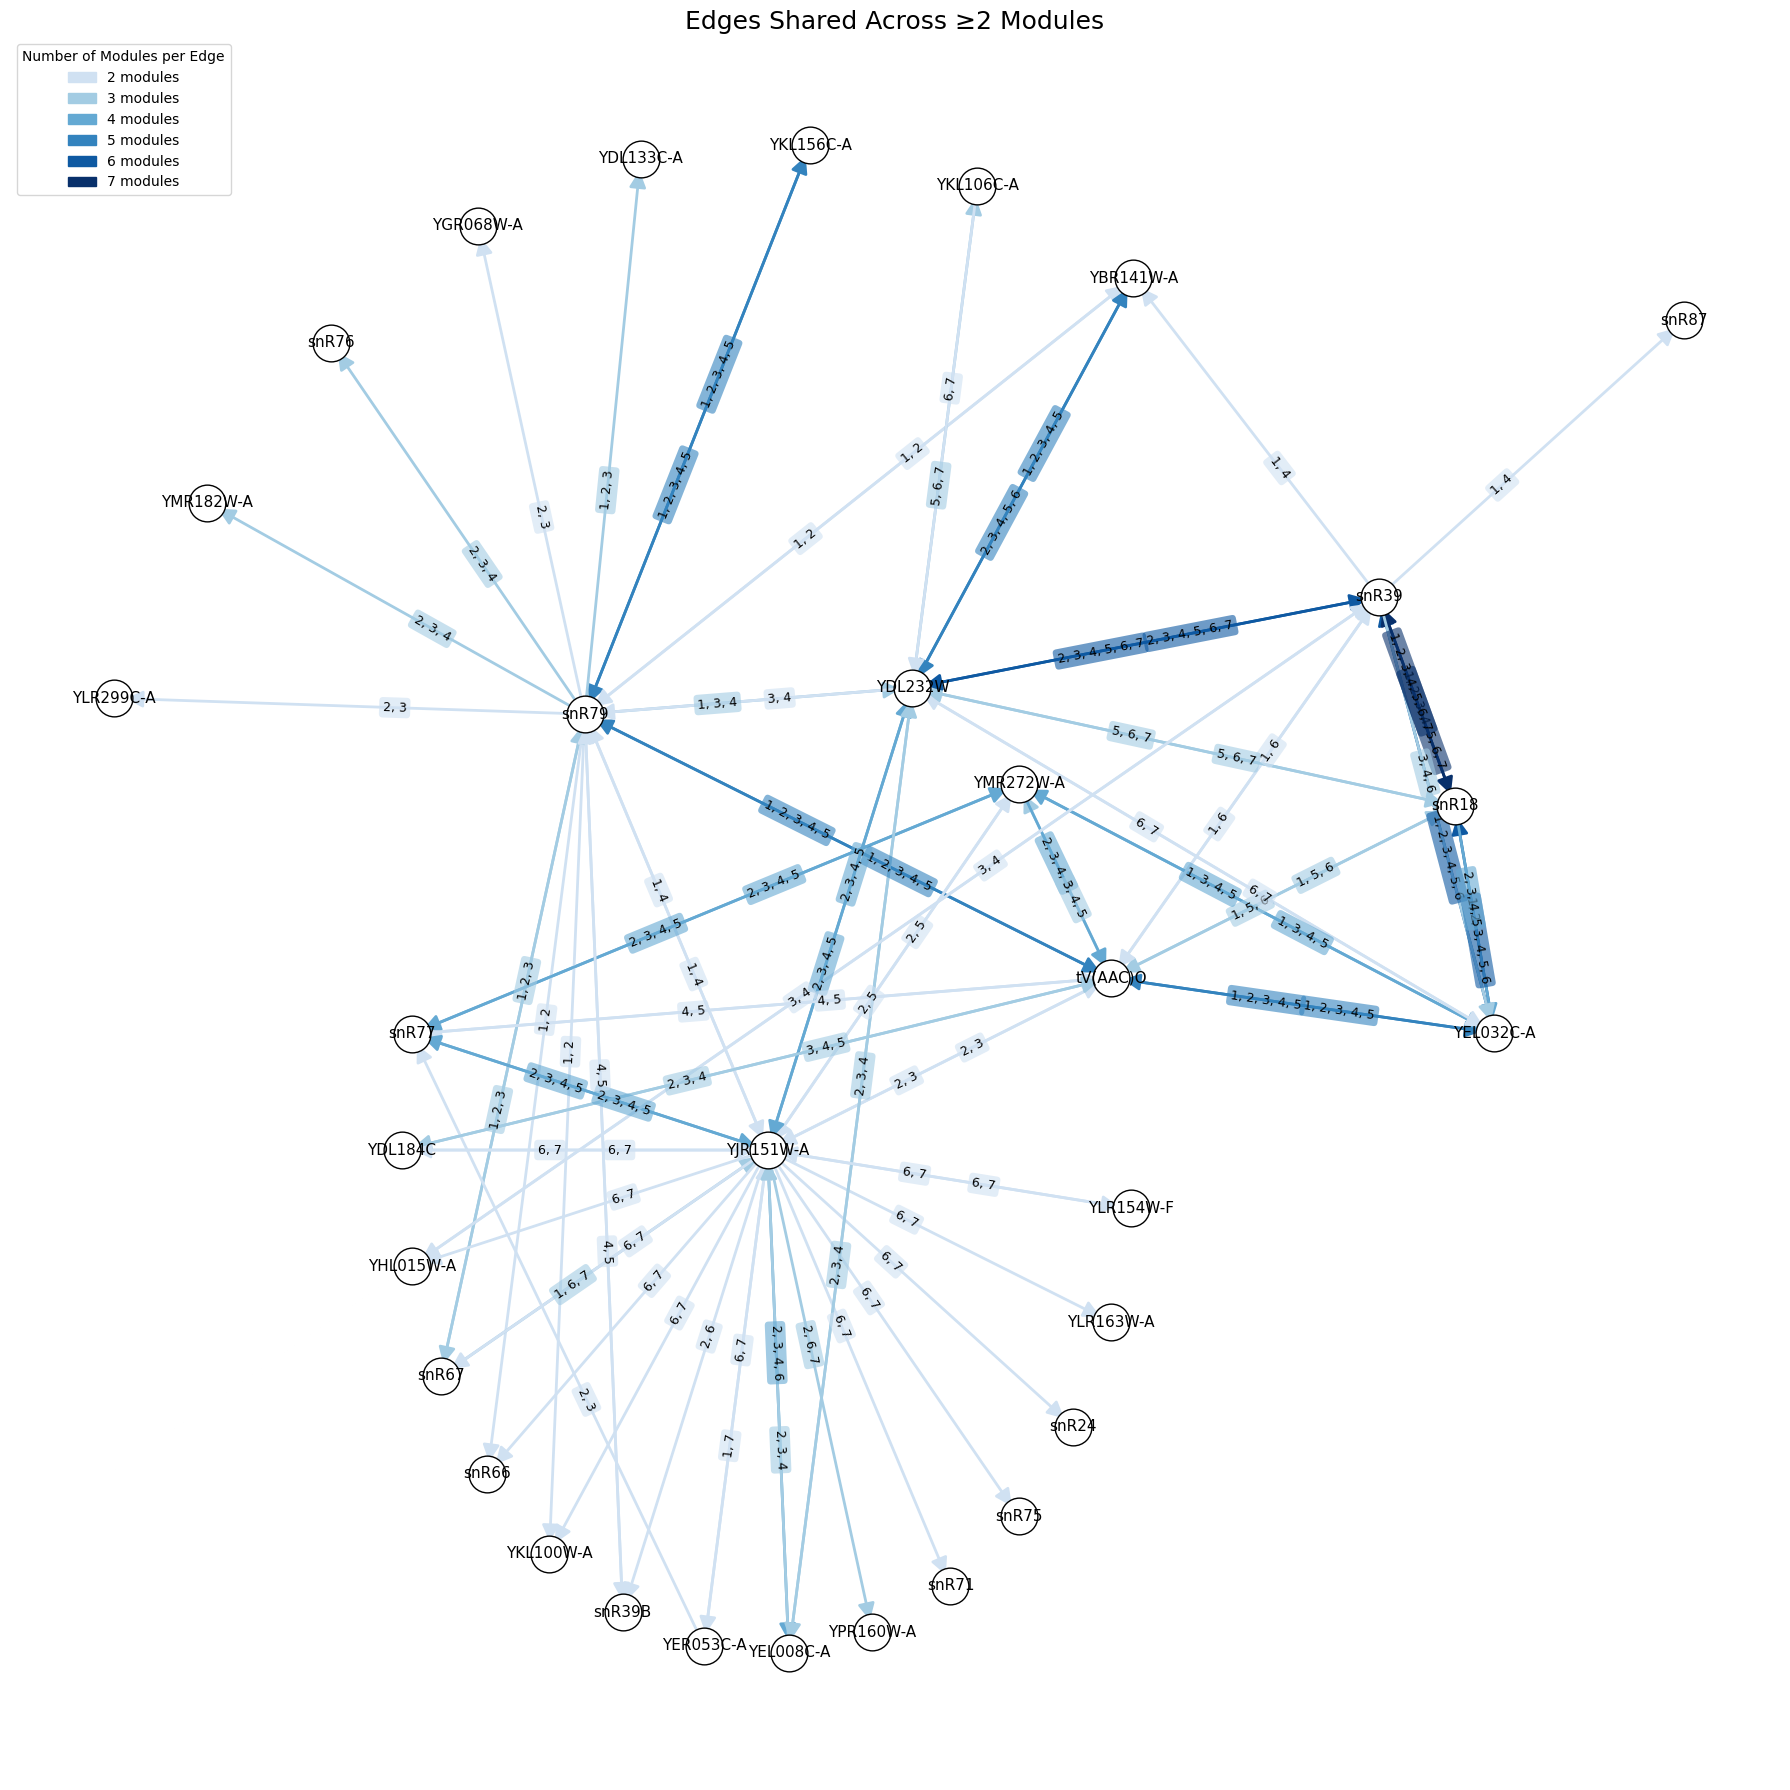

In [14]:
# multi module
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.patches import Patch

# === Load data ===
df = pd.read_csv("/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_10/Yeast_consolidated_scr10_r5_t0.1_biotype.csv")
# === Count edges and collect module sets ===
edge_counts = Counter()
edge_modules = defaultdict(set)
for _, row in df.iterrows():
    edge = (row["Regulator"], row["TargetGene"])
    edge_counts[edge] += 1
    edge_modules[edge].add(row["Module"])

# === Select only multi-module edges (≥2 modules) ===
multi_edges = {e for e, mods in edge_modules.items() if len(mods) >= 2}
df_multi = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in multi_edges, axis=1)]

# === Build graph ===
G = nx.DiGraph()
edge_module_sets = defaultdict(set)
for _, row in df_multi.iterrows():
    u, v, mod = row["Regulator"], row["TargetGene"], row["Module"]
    G.add_edge(u, v)
    edge_module_sets[(u, v)].add(mod)

# === Define edge color based on number of modules ===
def get_edge_color(modset, cmap, min_val=0.2, max_val=1.0):
    count = min(len(modset), 7)  # cap at 7 modules
    factor = (count - 2) / 5     # 2 mods → 0.0, 7 mods → 1.0
    return cmap(min_val + factor * (max_val - min_val))

cmap = plt.colormaps["Blues"]
edge_colors = { (u, v): get_edge_color(mods, cmap) for (u, v), mods in edge_module_sets.items() }

# === Layout ===
# Pick a root with lowest avg shortest path (excluding disconnected)
lengths = {}
nodes = list(G.nodes())
for node in nodes:
    sp = nx.single_source_shortest_path_length(G, node)
    if len(sp) > 1:
        avg = sum(sp.values()) / len(sp)
        lengths[node] = avg

root = min(lengths, key=lengths.get) if lengths else list(G.nodes())[0]
print("root node:", root)
pos = graphviz_layout(G, prog="twopi", root=root)

# === Plot ===
fig, ax = plt.subplots(figsize=(18, 18))

# Draw nodes
nx.draw_networkx_nodes(G, pos,
    node_color="white", edgecolors="black",
    node_size=700, ax=ax)

nx.draw_networkx_labels(G, pos,
    font_size=11, ax=ax)

# Draw curved edges if bidirectional
mutual_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u) and (v, u) not in mutual_edges:
        mutual_edges.add((u, v))

drawn_mutual = set()
for u, v in G.edges():
    color = edge_colors[(u, v)]
    connection = 'arc3,rad=0.1' if (v, u) in mutual_edges and (v, u) not in drawn_mutual else 'arc3,rad=0.0'
    drawn_mutual.add((u, v))
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        edge_color=[color],
        arrows=True,
        arrowstyle='-|>', arrowsize=25, width=2,
        connectionstyle=connection, ax=ax
    )

# Edge labels
edge_labels = {
    (u, v): ", ".join(sorted(str(mod) for mod in mods))
    for (u, v), mods in edge_module_sets.items()
}
for (u, v), label in edge_labels.items():
    color = edge_colors[(u, v)]
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels={(u, v): label},
        font_size=9, label_pos=0.4,
        bbox=dict(boxstyle='round', facecolor=color, edgecolor='none', alpha=0.6),
        ax=ax
    )

# Legend
legend = []
for i in range(2, 8):  # from 2 to 7 modules
    factor = (i - 2) / 5
    color = cmap(0.2 + factor * (1.0 - 0.2))
    legend.append(Patch(color=color, label=f"{i} modules"))

ax.legend(handles=legend, title="Number of Modules per Edge", loc="upper left", fontsize=10)

plt.title("Edges Shared Across ≥2 Modules", fontsize=18)
plt.axis("off")
plt.tight_layout()
print("Number of edges:", G.number_of_edges())
plt.show()


# Calculation for yeast data scr size 10 with no biotype

In [15]:
from collections import defaultdict, Counter
import networkx as nx
import pandas as pd

summary_data = []

for threshold, df in dfs.items():
    total_interactions = len(df)

    # === Multi-module calculation ===
    counts = df["Reg"].value_counts()
    multi_module_regulators = counts[counts > 1]
    num_multi_module = len(multi_module_regulators)
    total_multi_module_interactions = multi_module_regulators.sum()

    single_module_interactions = total_interactions - total_multi_module_interactions
    edge_reduction_by = ((total_multi_module_interactions - num_multi_module) / total_multi_module_interactions) * 100

    # === Filter only single-module interactions ===
    edge_counts = Counter()
    edge_modules = defaultdict(set)
    for _, row in df.iterrows():
        edge = (row["Regulator"], row["TargetGene"])
        edge_counts[edge] += 1
        edge_modules[edge].add(row["Module"])

    single_edges = {e for e, c in edge_counts.items() if c == 1}
    df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

    # === Build full graph before node aggregation ===
    G_full = nx.DiGraph()
    node_modules = defaultdict(list)
    edge_modules_single = defaultdict(set)
    for _, row in df_once.iterrows():
        u, v, mod = row["Regulator"], row["TargetGene"], row["Module"]
        G_full.add_edge(u, v)
        edge_modules_single[(u, v)].add(mod)
        node_modules[u].append(mod)
        node_modules[v].append(mod)

    node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
    terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

    grouped_targets = defaultdict(list)
    for u, v in G_full.edges():
        if v in terminal_nodes:
            grouped_targets[(u, node_cluster[v])].append(v)

    # === Build simplified graph with saggregated nodes ===
    G = nx.DiGraph()
    supernodes = {}

    for u, v in G_full.edges():
        if v in terminal_nodes:
            continue
        G.add_edge(u, v)

    for (reg, mod), targets in grouped_targets.items():
        if len(targets) == 1:
            v = targets[0]
            G.add_edge(reg, v)
        else:
            sn = f"group_{reg}_{mod}"
            G.add_edge(reg, sn)
            supernodes[sn] = targets

    # === Calculate edge reduction ===
    edges_before = len(G_full.edges())
    edges_after = len(G.edges())
    edge_reduction_supernodes = edges_before - edges_after
    percent_reduction_supernodes = (edge_reduction_supernodes / edges_before) * 100 if edges_before > 0 else 0

    # === Save summary ===
    summary_data.append({
    "Threshold": threshold,
    "Total Interactions": total_interactions,
    "Unique Multi-module Interactions": num_multi_module,
    "Total Multi-module Interactions": total_multi_module_interactions,
    "multi-modal percentage": round((total_multi_module_interactions / total_interactions) * 100, 2),
    "Edge Reduction from Combining Multi-module Interactions (%)": round(edge_reduction_by, 2),
    "Single Module Interactions": single_module_interactions,
     "Edges After Node Aggregation": edges_after,
    "Edge Reduction from Aggregated Nodes (%)": round(percent_reduction_supernodes, 2)
   
})


# === Create final dataframe ===
summary_df3 = pd.DataFrame(summary_data)
#summary_df.set_index("Threshold", inplace=True)
#summary_df = summary_df.sort_values(by="Threshold", key=lambda x: x.astype(float))
#summary_df.reset_index(drop=True, inplace=True)

summary_df3


,Threshold,Total Interactions,Unique Multi-module Interactions,Total Multi-module Interactions,multi-modal percentage,Edge Reduction from Combining Multi-module Interactions (%),Single Module Interactions,Edges After Node Aggregation,Edge Reduction from Aggregated Nodes (%)
0,0.1,337,87,266,78.93,67.29,71,64,9.86
1,0.05,1121,269,797,71.10,66.25,324,280,13.58
2,0.01,7015,1563,4238,60.41,63.12,2777,1627,41.41


In [16]:
# calculate median of multi module interactions in summary_df1, summary_df2 
# take all values from multi-module interactions column from all three dataframes
multi_module_values = (summary_df1["multi-modal percentage"].tolist() +
    summary_df2["multi-modal percentage"].tolist() 
)
median_multi_module = pd.Series(multi_module_values).median()
print(f"Median of multi-module interactions across all thresholds: {median_multi_module:.2f}%")

Median of multi-module interactions across all thresholds: 59.77%


Best root node (excluding supernodes): YOR302W
number of edges: 280
number of terminal nodes: 55


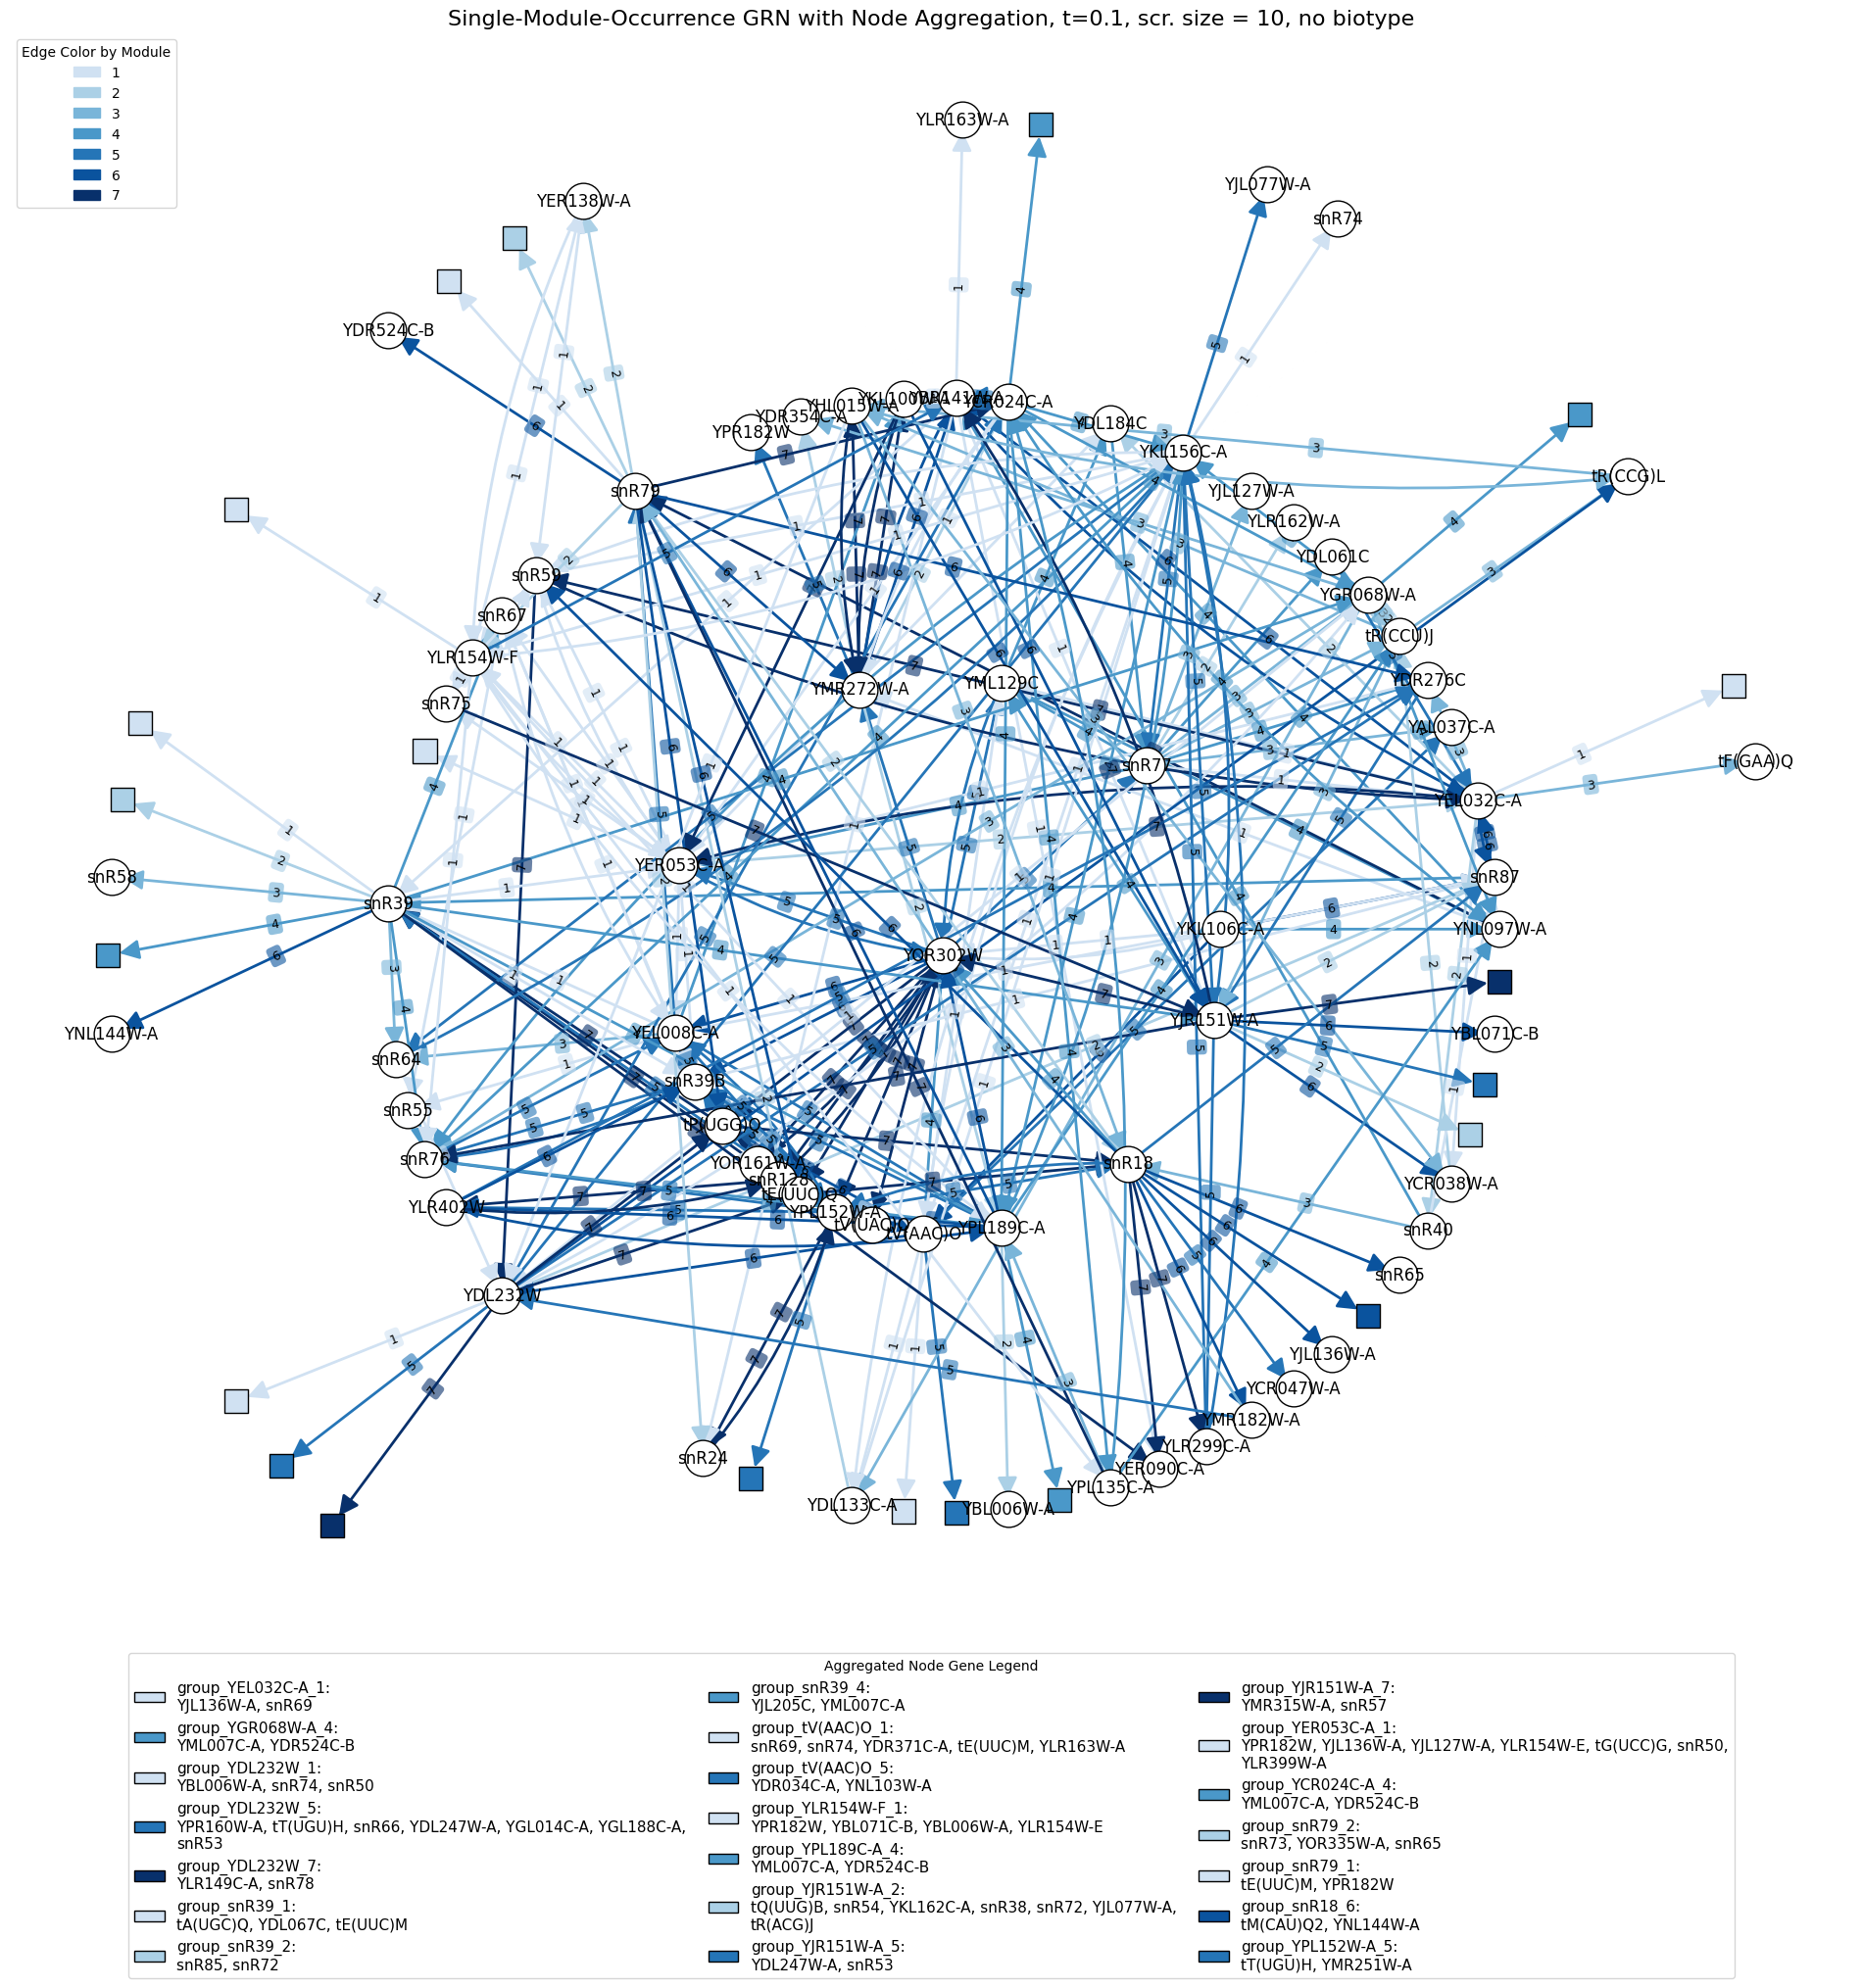

In [17]:
# example for 0.1 threshold, single module, no biotype
#yeast
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import textwrap
import matplotlib.gridspec as gridspec
import re

# === Load Data ===
df = pd.read_csv("/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_10/Yeast_consolidated_scr10_r5_t0.05_biotype.csv")

# === Count edges and collect modules ===
edge_counts = Counter()
edge_modules = defaultdict(set)
for _, row in df.iterrows():
    edge = (row["Regulator"], row["TargetGene"])
    edge_counts[edge] += 1
    edge_modules[edge].add(row["Module"])

# === Filter only single-occurrence edges ===
single_edges = {e for e, c in edge_counts.items() if c == 1}
df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

# === Build Graph from single-occurrence edges ===
G_full = nx.DiGraph()
node_modules = defaultdict(list)
edge_modules_single = defaultdict(set)
for _, row in df_once.iterrows():
    u, v, mod = row["Regulator"], row["TargetGene"], row["Module"]
    G_full.add_edge(u, v)
    edge_modules_single[(u, v)].add(mod)
    node_modules[u].append(mod)
    node_modules[v].append(mod)

# === Assign dominant module per node ===
node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

# === Group terminal targets for supernodes ===
grouped_targets = defaultdict(list)
for u, v in G_full.edges():
    if v in terminal_nodes:
        grouped_targets[(u, node_cluster[v])].append(v)

# === Build simplified graph ===
G = nx.DiGraph()
new_node_cluster = {}
new_edge_modules = {}
supernodes = {}
supernode_module = {}

for u, v in G_full.edges():
    if v in terminal_nodes:
        continue
    G.add_edge(u, v)
    new_edge_modules[(u, v)] = edge_modules_single[(u, v)]
    new_node_cluster[u] = node_cluster[u]
    new_node_cluster[v] = node_cluster[v]

for (reg, mod), targets in grouped_targets.items():
    if len(targets) == 1:
        v = targets[0]
        G.add_edge(reg, v)
        new_edge_modules[(reg, v)] = edge_modules_single[(reg, v)]
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[v] = node_cluster[v]
    else:
        sn = f"group_{reg}_{mod}"
        G.add_edge(reg, sn)
        new_edge_modules[(reg, sn)] = {mod}
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[sn] = mod
        supernodes[sn] = targets
        supernode_module[sn] = mod

# === Color Mapping ===
def natural_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split(r'(\d+)', s)]

all_modules = sorted({m for mods in new_edge_modules.values() for m in mods})
min_val, max_val = 0.2, 1.0
steps = len(all_modules) - 1 if len(all_modules) > 1 else 1
module_to_intensity = {
    mod: min_val + i * (max_val - min_val) / steps for i, mod in enumerate(all_modules)
}
cmap = plt.colormaps["Blues"]

# === Layout ===
#pos = graphviz_layout(G, prog="twopi", root='MT-CO3')
# === Identify optimal root node (minimum average shortest path length, exclude supernodes) ===
try:
    candidate_nodes = [n for n in G.nodes() if n not in supernodes]
    lengths = {}

    for node in candidate_nodes:
        sp = nx.single_source_shortest_path_length(G, node)
        # Only count shortest paths to other non-supernodes
        reachable = [t for t in sp if t != node and t not in supernodes]
        if reachable:
            avg_length = sum(sp[t] for t in reachable) / len(reachable)
            lengths[node] = avg_length

    best_root = min(lengths, key=lengths.get)
    print(f"Best root node (excluding supernodes): {best_root}")
except:
    best_root = candidate_nodes[0] if candidate_nodes else list(G.nodes())[0]
    print("No valid root found — using fallback.")


pos = graphviz_layout(G, prog="twopi", root=best_root)

# === Create Figure ===
fig = plt.figure(figsize=(20, 26))
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 1])
ax_graph = plt.subplot(gs[0])
ax_legend = plt.subplot(gs[1])
ax_legend.axis("off")

# === Draw Nodes ===
regular_nodes = [n for n in G.nodes() if n not in supernodes]
supernode_list = list(supernodes)

nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes,
                       node_color="white", edgecolors="black",
                       node_shape='o', node_size=700, ax=ax_graph)

nx.draw_networkx_nodes(G, pos, nodelist=supernode_list,
    node_color=[cmap(module_to_intensity[supernode_module[n]]) for n in supernode_list],
    edgecolors="black", node_shape='s', node_size=300, ax=ax_graph)

nx.draw_networkx_labels(G, pos, labels={n: n for n in regular_nodes},
                        font_size=12, ax=ax_graph)

# === Identify bidirectional edges ===
mutual_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u) and (v, u) not in mutual_edges:
        mutual_edges.add((u, v))

# === Precompute edge colors ===
edge_to_color = {}
for u, v in G.edges():
    modules = sorted(new_edge_modules.get((u, v), []))
    if modules:
        avg_intensity = sum(module_to_intensity[m] for m in modules) / len(modules)
        edge_to_color[(u, v)] = cmap(avg_intensity)

# === Draw Edges ===
drawn_mutual = set()
for u, v, data in G.edges(data=True):
    edge_color = edge_to_color[(u, v)]

    # Use curved line if it's the second in a mutual pair
    if (v, u) in mutual_edges and (v, u) not in drawn_mutual:
        connection = 'arc3,rad=0.1'
        drawn_mutual.add((u, v))
    else:
        connection = 'arc3,rad=0.0'

    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        edge_color=[edge_color], arrows=True,
        arrowstyle='-|>', arrowsize=30, width=2,
        connectionstyle=connection, ax=ax_graph
    )

# === Edge Labels with Matching Colors ===
edge_labels = {(u, v): ", ".join(sorted(map(str, mods))) for (u, v), mods in new_edge_modules.items()}
for (u, v), label in edge_labels.items():
    edge_color = edge_to_color.get((u, v), "white")
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels={(u, v): label},
        font_size=9, label_pos=0.4,
        bbox=dict(boxstyle='round',
                  facecolor=edge_color,
                  edgecolor='none',
                  alpha=0.6),
        ax=ax_graph
    )

ax_graph.set_title("Single-Module-Occurrence GRN with Node Aggregation, t=0.1, scr. size = 10, no biotype", fontsize=16)
ax_graph.axis("off")

# === Legends ===
legend_lines = [
    Patch(color=cmap(module_to_intensity[m]), label=m) for m in all_modules
]

legend_supernodes = []
supernode_labels = []
for sn in supernode_list:
    mod = supernode_module[sn]
    targets = supernodes[sn]
    wrapped = "\n".join(textwrap.wrap(", ".join(targets), width=60))
    color = cmap(module_to_intensity[mod])
    legend_supernodes.append(Patch(facecolor=color, edgecolor='black'))
    supernode_labels.append(f"{sn}:\n{wrapped}")

ax_graph.legend(handles=legend_lines, title="Edge Color by Module", loc='upper left')

legend_super = ax_legend.legend(
    handles=legend_supernodes, labels=supernode_labels,
    loc='upper center', bbox_to_anchor=(0.5, 1.12),
    fontsize=11, title="Aggregated Node Gene Legend", ncol=3,
    frameon=True, columnspacing=1.5
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, bottom=0.2, top=0.95)
print('number of edges:', G.number_of_edges())
print('number of terminal nodes:', len(terminal_nodes))
plt.show()


# Calculation for yeast data scr size 10 with biotype

Number of edges: 298
Number of terminal nodes: 55


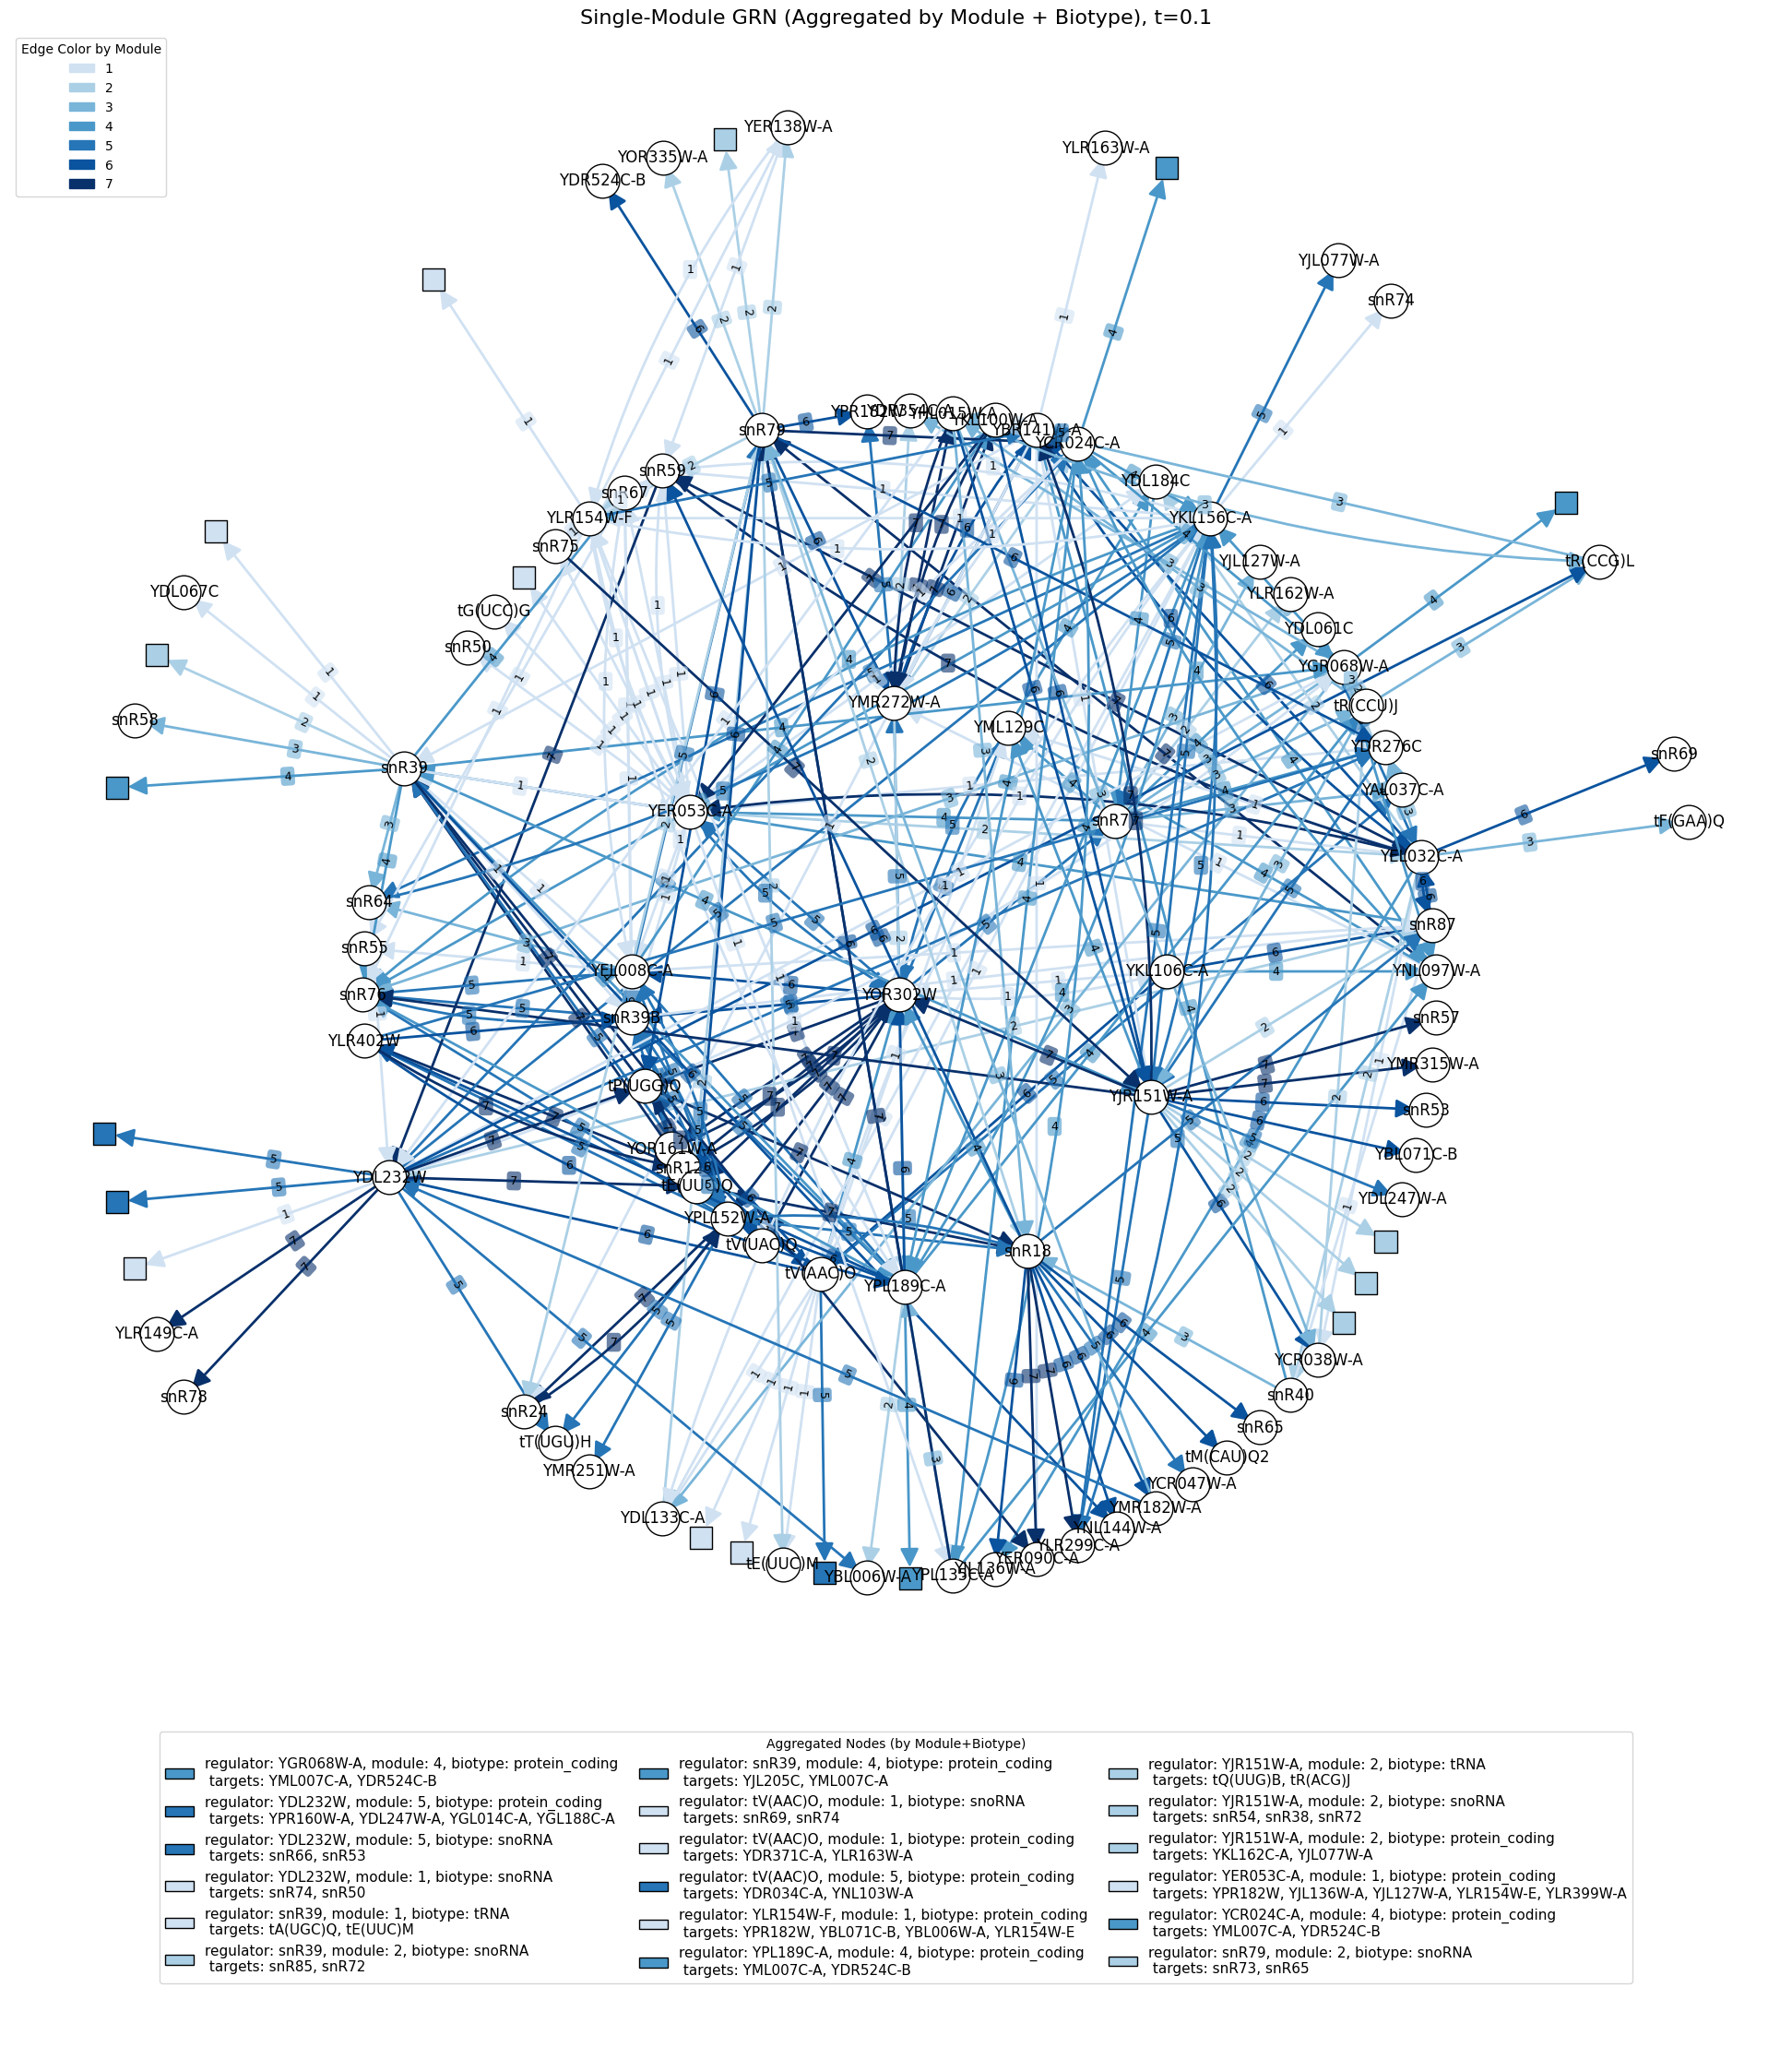

In [18]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.patches import Patch
import textwrap
import matplotlib.gridspec as gridspec
import numpy as np

# === Load Data ===
df = pd.read_csv("/Users/irmaskaljo/codedev/thesis/Data_preprocessing/Yeast/scr_size_10/Yeast_consolidated_scr10_r5_t0.05_biotype.csv")

# === Count edges and collect modules ===
edge_counts = Counter()
edge_modules = defaultdict(set)
for _, row in df.iterrows():
    edge = (row["Regulator"], row["TargetGene"])
    edge_counts[edge] += 1
    edge_modules[edge].add(row["Module"])

# === Filter only single-occurrence edges ===
single_edges = {e for e, c in edge_counts.items() if c == 1}
df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

# === Build Graph from single-occurrence edges ===
G_full = nx.DiGraph()
node_modules = defaultdict(list)
edge_modules_single = defaultdict(set)

for _, row in df_once.iterrows():
    u, v, mod, bio = row["Regulator"], row["TargetGene"], row["Module"], row["TargetBiotype"]
    G_full.add_edge(u, v)
    edge_modules_single[(u, v)].add(mod)
    node_modules[u].append(mod)
    node_modules[v].append(mod)

# === Assign dominant module per node ===
node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

# === Group terminal targets by (regulator, module, biotype) ===
grouped_targets = defaultdict(list)
target_type_map = dict(zip(df["TargetGene"], df["TargetBiotype"]))

for u, v in G_full.edges():
    if v in terminal_nodes:
        mod = node_cluster[v]  # dominant module of target
        biotype = target_type_map.get(v, "Unknown")
        grouped_targets[(u, mod, biotype)].append(v)

# === Build simplified graph ===
G = nx.DiGraph()
new_node_cluster = {}
new_edge_modules = {}
aggregated_nodes = {}
aggregated_node_info = {}  # store (module, biotype) for legend

for u, v in G_full.edges():
    if v in terminal_nodes:
        continue
    G.add_edge(u, v)
    new_edge_modules[(u, v)] = edge_modules_single[(u, v)]
    new_node_cluster[u] = node_cluster[u]
    new_node_cluster[v] = node_cluster[v]

for (reg, mod, biotype), targets in grouped_targets.items():
    if len(targets) == 1:
        v = targets[0]
        G.add_edge(reg, v)
        new_edge_modules[(reg, v)] = edge_modules_single[(reg, v)]
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[v] = node_cluster[v]
    else:
        agg_node = f"group_{reg}_{mod}_{biotype}"
        G.add_edge(reg, agg_node)
        new_edge_modules[(reg, agg_node)] = {mod}
        new_node_cluster[reg] = node_cluster[reg]
        new_node_cluster[agg_node] = mod
        aggregated_nodes[agg_node] = targets
        aggregated_node_info[agg_node] = (mod, biotype)

# === Color Mapping ===
all_modules = sorted({m for mods in new_edge_modules.values() for m in mods})
min_val, max_val = 0.2, 1.0
steps = len(all_modules) - 1 if len(all_modules) > 1 else 1
module_to_intensity = {
    mod: min_val + i * (max_val - min_val) / steps
    for i, mod in enumerate(all_modules)
}
cmap = plt.colormaps["Blues"]

# === Layout ===
try:
    candidate_nodes = [n for n in G.nodes() if n not in aggregated_nodes]
    lengths = {}
    for node in candidate_nodes:
        sp = nx.single_source_shortest_path_length(G, node)
        reachable = [t for t in sp if t != node and t not in aggregated_nodes]
        if reachable:
            avg_length = sum(sp[t] for t in reachable) / len(reachable)
            lengths[node] = avg_length
    best_root = min(lengths, key=lengths.get)
except:
    best_root = candidate_nodes[0] if candidate_nodes else list(G.nodes())[0]

pos = graphviz_layout(G, prog="twopi", root=best_root)

# === Draw Graph ===
fig = plt.figure(figsize=(20, 29))
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 1])
ax_graph = plt.subplot(gs[0])
ax_legend = plt.subplot(gs[1])
ax_legend.axis("off")

regular_nodes = [n for n in G.nodes() if n not in aggregated_nodes]
agg_node_list = list(aggregated_nodes)

nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes,
                       node_color="white", edgecolors="black", node_shape='o',
                       node_size=700, ax=ax_graph)
nx.draw_networkx_nodes(G, pos, nodelist=agg_node_list,
                       node_color=[cmap(module_to_intensity[new_node_cluster[n]]) for n in agg_node_list],
                       edgecolors="black", node_shape='s', node_size=300, ax=ax_graph)
nx.draw_networkx_labels(G, pos,
                        labels={n: n for n in regular_nodes},
                        font_size=12, ax=ax_graph)

# === Edge drawing ===
mutual_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u) and (v, u) not in mutual_edges:
        mutual_edges.add((u, v))

edge_to_color = {}
for u, v in G.edges():
    modules = sorted(new_edge_modules.get((u, v), []))
    if modules:
        avg_intensity = sum(module_to_intensity[m] for m in modules) / len(modules)
        edge_to_color[(u, v)] = cmap(avg_intensity)

for u, v, data in G.edges(data=True):
    edge_color = edge_to_color[(u, v)]
    connection = 'arc3,rad=0.1' if (v, u) in mutual_edges else 'arc3,rad=0.0'
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                           edge_color=[edge_color], arrows=True,
                           arrowstyle='-|>', arrowsize=30, width=2,
                           connectionstyle=connection, ax=ax_graph)

# === Edge labels ===
def curved_label_pos(pos_src, pos_dst, curvature=0.03, label_pos=0.4):
    dx = pos_dst[0] - pos_src[0]
    dy = pos_dst[1] - pos_src[1]
    mx = pos_src[0] + dx * label_pos
    my = pos_src[1] + dy * label_pos
    perp_dx = dy
    perp_dy = -dx
    norm = np.hypot(perp_dx, perp_dy)
    if norm == 0:
        return (mx, my)
    offset = curvature * np.sqrt(dx**2 + dy**2)
    label_x = mx + perp_dx / norm * offset
    label_y = my + perp_dy / norm * offset
    return (label_x, label_y)

edge_labels = {(u, v): ", ".join(sorted(map(str, mods))) for (u, v), mods in new_edge_modules.items()}

for (u, v), label in edge_labels.items():
    edge_color = edge_to_color.get((u, v), "white")
    if (v, u) in mutual_edges:
        x, y = curved_label_pos(pos[u], pos[v], curvature=0.05, label_pos=0.4)
        ax_graph.text(x, y, label, fontsize=9,
                      bbox=dict(boxstyle='round', facecolor=edge_color, edgecolor='none', alpha=0.6),
                      horizontalalignment='center')
    else:
        nx.draw_networkx_edge_labels(G, pos,
                                     edge_labels={(u, v): label},
                                     font_size=9, label_pos=0.4,
                                     bbox=dict(boxstyle='round', facecolor=edge_color,
                                               edgecolor='none', alpha=0.6),
                                     ax=ax_graph)

# === Final Touches ===
ax_graph.set_title("Single-Module GRN (Aggregated by Module + Biotype), t=0.1", fontsize=16)
ax_graph.axis("off")

# === Legend for modules ===
legend_lines = [Patch(color=cmap(module_to_intensity[m]), label=m) for m in all_modules]

# === Aggregated node legend ===
legend_aggregated = []
aggregated_labels = []
for agg in agg_node_list:
    mod, biotype = aggregated_node_info.get(agg, ("Unknown", "Unknown"))
    targets = aggregated_nodes.get(agg, [])
    regulator_gene = agg.split("_")[1] if "_" in agg else "Unknown"
    header = f"regulator: {regulator_gene}, module: {mod}, biotype: {biotype}"
    wrapped = "\n".join(textwrap.wrap(", ".join(targets), width=60))
    label = f"{header}\n targets: {wrapped}"
    color = cmap(module_to_intensity[mod])
    legend_aggregated.append(Patch(facecolor=color, edgecolor='black'))
    aggregated_labels.append(label)

# === Show legends ===
ax_graph.legend(handles=legend_lines, title="Edge Color by Module", loc='upper left')
ax_legend.legend(handles=legend_aggregated, labels=aggregated_labels,
                 loc='upper center', bbox_to_anchor=(0.5, 1.12),
                 fontsize=11, title="Aggregated Nodes (by Module+Biotype)",
                 ncol=3, frameon=True, columnspacing=1.5)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, bottom=0.2, top=0.95)

print('Number of edges:', G.number_of_edges())
print('Number of terminal nodes:', len(terminal_nodes))

plt.show()


In [32]:
from collections import defaultdict, Counter
import networkx as nx
import pandas as pd

dfs = {
    "0.1": df1,
    "0.05": df2
}

summary_data = []

for threshold, df in dfs.items():
    total_interactions = len(df)

    # === Multi-module calculation ===
    counts = df["Reg"].value_counts()
    multi_module_regulators = counts[counts > 1]
    num_multi_module = len(multi_module_regulators)
    total_multi_module_interactions = multi_module_regulators.sum()

    single_module_interactions = total_interactions - total_multi_module_interactions
    edge_reduction_by = ((total_multi_module_interactions - num_multi_module) / total_multi_module_interactions) * 100

    # === Filter only single-module interactions ===
    edge_counts = Counter()
    edge_modules = defaultdict(set)
    for _, row in df.iterrows():
        edge = (row["Regulator"], row["TargetGene"])
        edge_counts[edge] += 1
        edge_modules[edge].add(row["Module"])

    single_edges = {e for e, c in edge_counts.items() if c == 1}
    df_once = df[df.apply(lambda row: (row["Regulator"], row["TargetGene"]) in single_edges, axis=1)]

    # === Build full graph before node aggregation ===
    G_full = nx.DiGraph()
    node_modules = defaultdict(list)
    edge_modules_single = defaultdict(set)

    for _, row in df_once.iterrows():
        u, v, mod, bio = row["Regulator"], row["TargetGene"], row["Module"], row["TargetBiotype"]
        G_full.add_edge(u, v)
        edge_modules_single[(u, v)].add(mod)
        node_modules[u].append(mod)
        node_modules[v].append(mod)

    node_cluster = {n: Counter(mods).most_common(1)[0][0] for n, mods in node_modules.items()}
    terminal_nodes = [n for n in G_full.nodes() if G_full.out_degree(n) == 0]

    # === Group terminal targets by (regulator, module, biotype) ===
    grouped_targets = defaultdict(list)
    target_type_map = dict(zip(df["TargetGene"], df["TargetBiotype"]))

    for u, v in G_full.edges():
        if v in terminal_nodes:
            mod = node_cluster[v]
            biotype = target_type_map.get(v, "Unknown")
            grouped_targets[(u, mod, biotype)].append(v)

    # === Build simplified graph with aggregated nodes ===
    G = nx.DiGraph()
    supernodes = {}

    for u, v in G_full.edges():
        if v in terminal_nodes:
            continue
        G.add_edge(u, v)

    for (reg, mod, biotype), targets in grouped_targets.items():
        if len(targets) == 1:
            v = targets[0]
            G.add_edge(reg, v)
        else:
            sn = f"group_{reg}_{mod}_{biotype}"
            G.add_edge(reg, sn)
            supernodes[sn] = targets

    # === Calculate edge reduction ===
    edges_before = len(G_full.edges())
    edges_after = len(G.edges())
    edge_reduction_supernodes = edges_before - edges_after
    percent_reduction_supernodes = (edge_reduction_supernodes / edges_before) * 100 if edges_before > 0 else 0

    # === Save summary ===
    summary_data.append({
        "Threshold": threshold,
        "Total Interactions": total_interactions,
        "Unique Multi-module Interactions": num_multi_module,
        "Total Multi-module Interactions": total_multi_module_interactions,
        "multi-modal percentage": round((total_multi_module_interactions / total_interactions) * 100, 2),
        "Edge Reduction from Combining Multi-module Interactions (%)": round(edge_reduction_by, 2),
        "Single Module Interactions": single_module_interactions,
        "Edges After Node Aggregation": edges_after,
        "Edge Reduction from Aggregated Nodes (%)": round(percent_reduction_supernodes, 2)
    })

# === Create final dataframe ===
summary_df = pd.DataFrame(summary_data)
#summary_df.set_index("Threshold", inplace=True)
#summary_df = summary_df.sort_values(by="Threshold", key=lambda x: x.astype(float))
#summary_df.reset_index(drop=True, inplace=True)

summary_df


,Threshold,Total Interactions,Unique Multi-module Interactions,Total Multi-module Interactions,multi-modal percentage,Edge Reduction from Combining Multi-module Interactions (%),Single Module Interactions,Edges After Node Aggregation,Edge Reduction from Aggregated Nodes (%)
0,0.1,337,87,266,78.93,67.29,71,66,7.04
1,0.05,1121,269,797,71.10,66.25,324,298,8.02


In [ ]:
# calculate median of multi modal percentage
median_multi_modal = summary_df["multi-modal percentage"].median()
print(f"Median Multi-modal Percentage: {median_multi_modal:.2f}%")